[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A12_insurance_pricing.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's twelfth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `statsmodels`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A12 (IA) — Pricing Risk: Frequency × Severity, Loss Ratios & Adverse Selection

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

The B2B webshop from NB 25 — the one whose prices A1 set, whose credit A3 underwrote and whose buying office A8 audited — now sells something it does not stock: a **3-year device protection plan** on the IT equipment it ships. Accidental damage, breakdown, liquid, theft. Sixty thousand plans are in force, every one of them priced at **€89 a plan-year**, whatever the device and whoever the customer. Finance's quarterly pack shows the product making money. The claims team's spreadsheet shows one corner of the book paying out more than twice what it collects. Both are right, and product management wants to know what the plan *should* cost.

This is A3's problem grown a dimension. A3 modelled a **binary** event — the customer defaults or doesn't — with one loss given default, and produced a **binary decision**: approve or decline. Here the loss is a **count times an amount**, both random and modelled separately; the amount is drawn from a distribution whose mean sits at the 72nd percentile; and the decision isn't yes/no but a **number**, one you have to be able to defend to a product committee, a reseller channel and a regulator. There is also a trap A3 never faces. A lender that refuses to differentiate simply loses money on bad borrowers. An insurer that refuses to differentiate loses its **good** risks — to whoever *does* differentiate — and then loses money on everyone who stayed. That mechanism has a name and a body count, and §6 simulates it.

> 🧠 **Mental model.** A premium is three numbers stacked: **how often** (frequency, per unit of *time at risk*), **how much** (severity, from a distribution with a tail that will not average away), and **what you must add** so the business survives being right on average (expenses and capital). Get the units wrong on the first — count claims per *policy* instead of per *policy-year* — and every number downstream is wrong by the same factor. Get the second wrong by trusting a mean, and one theft in one cell rewrites a rate table. Get the price *right on average but wrong per customer*, and the market itself will take the customers you wanted and leave you the ones you didn't.

## 🎯 Learning objectives

By the end you can:

1. Read an insurance book the way an actuary does — **written vs earned premium, incurred claims, loss ratio, expense ratio, combined ratio** — and say which corner of a portfolio is losing money while the total looks fine.
2. Explain why **exposure** is the actuarial twin of A5's censoring, compute an **exposure-weighted frequency**, and quantify what ignoring it costs (here: a 38.9 % understatement).
3. Fit a **Poisson GLM with a log-exposure offset** in `statsmodels`, recover planted rate relativities, run a **dispersion check**, and say precisely what overdispersion damages (the confidence intervals) and what it leaves alone (the point estimates).
4. Model **severity** with a Gamma GLM, explain why its mean is a bad summary of a fat-tailed distribution, and apply **large-loss capping** — while being explicit that a cap does not delete a loss, it *moves* it.
5. Assemble a **technical price** — pure premium = frequency × severity, plus expense and capital loadings — build a rate table, and price the **cross-subsidy** hidden inside a flat price, in € per policy and € across the book.
6. Simulate **adverse selection**, watch a flat-priced book's loss ratio cross 100 % over five renewal cycles, and write the rate table as a decision — with A3's fairness discipline (permissible ≠ predictive) and a capped year-over-year increase, both priced.

## ✅ Prerequisites

**A3** (this notebook's closest sibling — expected loss, a decision derived from economics, and the proxy-discrimination discipline we import wholesale in §6) and **A5 §2** (censoring; §2 here is the same idea in a different industry's vocabulary). **A1** for price response and elasticity, which §6's lapse model borrows. **NB 10** for confidence intervals, **NB 17–18** for the honest-evaluation habits assumed throughout. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

PRICE_FLAT = 89.0        # what every DeviceCare plan costs today, EUR per plan-year
EXP_FIX = 7.50           # fixed cost of servicing one plan-year (admin + claims handling), EUR
EXP_VAR = 0.14           # variable expense: reseller commission + acquisition, share of premium
CAP_LOAD = 0.06          # cost-of-capital / underwriting profit margin, share of premium
LOAD_DIV = 1 - EXP_VAR - CAP_LOAD           # divide the loaded pure premium by this
LARGE_LOSS_CAP = 2_500.0 # single-claim cap used to price the working layer (SS4)

PALETTE = {"consumer": "#8da0cb", "SME": "#66c2a5", "trade": "#fc8d62"}

print(f"Flat price EUR {PRICE_FLAT:.0f} per plan-year. Expenses: EUR {EXP_FIX:.2f} fixed + "
      f"{EXP_VAR:.0%} of premium; capital load {CAP_LOAD:.0%}.")
print(f"technical price = (pure premium + {EXP_FIX:.2f}) / {LOAD_DIV:.2f}"
      f"   <- everything in this notebook ends in this formula")

Flat price EUR 89 per plan-year. Expenses: EUR 7.50 fixed + 14% of premium; capital load 6%.
technical price = (pure premium + 7.50) / 0.80   <- everything in this notebook ends in this formula


## 1. The business: 60,000 plans, one price, and a loss ratio nobody owns

**DeviceCare** is the webshop's own protection plan, sold at checkout on laptops, monitors and printers: three years of cover against accidental damage, breakdown, liquid ingress and theft, billed at **€89 per plan-year**. One price. No questions about the device, the customer or how the kit will be used.

The book has been growing fast, which matters more than it sounds — hold that thought until §2. What we have is one row per plan and one row per claim:

| Field | What it is |
|---|---|
| `device`, `device_value` | laptop / monitor / printer, and its replacement value |
| `segment` | `consumer`, `SME`, or `trade` — the heavy-use trades (site work, workshops, mobile fitters) |
| `channel` | how the plan was sold: `webshop`, `reseller`, `telesales` |
| `district` | where the kit lives: `inner city`, `suburban`, `rural` |
| `usage` | hours of use per day, as declared at sale |
| `months_in_force` | months since the plan incepted |
| `exposure` | **the fraction of the current year this plan was actually on risk** — the column §2 is about |
| `credit_band` | a bought-in affluence/credit score the product team wants to rate on (§6 audits it) |
| `claims`, `incurred` | claim count and total paid, this year |

Because we simulate the book, the generator **plants the truth** — the frequency multiplier of each rating factor, and the severity distribution behind each claim — so §3 and §4 can be checked against numbers we control. Every business figure, though, is computed from the book alone, exactly as you would in production.

In [2]:
DEVICES = {"laptop": 0.45, "monitor": 0.33, "printer": 0.22}
SEGMENTS = {"consumer": 0.46, "SME": 0.40, "trade": 0.14}
CHANNELS = {"webshop": 0.55, "reseller": 0.30, "telesales": 0.15}
DISTRICTS = {"inner city": 0.42, "suburban": 0.38, "rural": 0.20}

# ---- planted truth: the annual claim RATE is a product of relativities ----
FREQ_BASE = 0.0956
FREQ_DEVICE = {"laptop": 1.30, "monitor": 0.70, "printer": 1.00}
FREQ_SEGMENT = {"consumer": 1.00, "SME": 1.22, "trade": 1.75}
FREQ_CHANNEL = {"webshop": 1.00, "reseller": 1.05, "telesales": 1.18}
FREQ_DISTRICT = {"inner city": 1.20, "suburban": 0.96, "rural": 0.78}
FREQ_USAGE, USAGE_REF = 0.09, 5.0      # log-linear in declared hours/day
FRAILTY_SHAPE = 0.35                   # unobserved heterogeneity -> overdispersion (SS3)

# ---- planted truth: severity is lognormal, plus rare catastrophes ----
SEV_MEDIAN = {"laptop": 330.0, "monitor": 175.0, "printer": 195.0}
SEV_SEGMENT = {"consumer": 1.00, "SME": 1.05, "trade": 1.12}
SEV_SIGMA, CAT_RATE = 0.95, 0.004      # 0.4% of claims are fleet thefts / batch defects

USAGE_MEAN = {"consumer": 3.5, "SME": 5.0, "trade": 7.5}
USAGE_SD = {"consumer": 2.0, "SME": 2.0, "trade": 2.5}
DEV_VALUE = {"laptop": 1400.0, "monitor": 350.0, "printer": 600.0}
GROWTH = 1.10                          # monthly growth in new plans sold -> young book
CAUSES = ["accidental damage", "breakdown", "liquid damage", "theft"]


def build_book(n=60_000, seed=35):
    """One policy year of DeviceCare. Returns (policies, claims).

    `exposure` is the share of THIS year the plan was on risk: a plan sold in
    September has been at risk for a third of a year, and its claim count must
    be read against that, not against a full year (SS2).
    """
    rng = np.random.default_rng(seed)
    device = rng.choice(list(DEVICES), n, p=list(DEVICES.values()))
    segment = rng.choice(list(SEGMENTS), n, p=list(SEGMENTS.values()))
    channel = rng.choice(list(CHANNELS), n, p=list(CHANNELS.values()))
    district = rng.choice(list(DISTRICTS), n, p=list(DISTRICTS.values()))
    usage = rng.normal([USAGE_MEAN[s] for s in segment],
                       [USAGE_SD[s] for s in segment]).clip(0.5, 14.0).round(1)

    ago = np.arange(1, 37)                          # months since inception, 1..36
    w = GROWTH ** (36 - ago)                        # the book grew -> recent months dominate
    months_in_force = rng.choice(ago, n, p=w / w.sum())
    exposure = np.minimum(months_in_force, 12) / 12.0

    lam = (FREQ_BASE
           * np.array([FREQ_DEVICE[d] for d in device])
           * np.array([FREQ_SEGMENT[s] for s in segment])
           * np.array([FREQ_CHANNEL[c] for c in channel])
           * np.array([FREQ_DISTRICT[d] for d in district])
           * np.exp(FREQ_USAGE * (usage - USAGE_REF)))
    frailty = rng.gamma(FRAILTY_SHAPE, 1 / FRAILTY_SHAPE, n)     # mean 1, heavy spread
    counts = rng.poisson(lam * frailty * exposure)               # <- exposure multiplies the RATE

    # a bought-in score that is a FUNCTION of segment/district/channel and nothing else
    lean = (1.00 * pd.Series(segment).map({"consumer": 0.0, "SME": 0.5, "trade": 1.0}).to_numpy()
            + 0.80 * pd.Series(district).map({"rural": 0.0, "suburban": 0.4, "inner city": 1.0}).to_numpy()
            + 0.45 * pd.Series(channel).map({"webshop": 0.0, "reseller": 0.3, "telesales": 1.0}).to_numpy()
            + rng.normal(0, 0.40, n))
    credit_band = np.where(lean > np.quantile(lean, 0.67), "weak",
                           np.where(lean > np.quantile(lean, 0.33), "average", "strong"))

    policies = pd.DataFrame(dict(
        device=device, segment=segment, channel=channel, district=district, usage=usage,
        months_in_force=months_in_force, exposure=exposure.round(4),
        device_value=[DEV_VALUE[d] for d in device], credit_band=credit_band, claims=counts))
    policies["lam_true"] = lam                       # god mode: for checking SS3 only

    idx = np.repeat(np.arange(n), counts)            # one row per claim
    med = (np.array([SEV_MEDIAN[d] for d in device])[idx]
           * np.array([SEV_SEGMENT[s] for s in segment])[idx])
    amount = rng.lognormal(np.log(med), SEV_SIGMA)
    cause = rng.choice(CAUSES, idx.size, p=[0.46, 0.34, 0.12, 0.08])
    cat = rng.random(idx.size) < CAT_RATE            # a stolen fleet, a firmware batch defect
    amount = np.where(cat, rng.uniform(4_000, 26_000, idx.size), amount)
    cause = np.where(cat, rng.choice(["theft (fleet)", "batch defect"], idx.size), cause)
    claims = pd.DataFrame(dict(policy=idx, device=policies.device.to_numpy()[idx],
                               segment=policies.segment.to_numpy()[idx],
                               cause=cause, amount=amount.round(2)))
    return policies, claims


pol, clm = build_book()
pol["incurred"] = clm.groupby("policy").amount.sum().reindex(range(len(pol))).fillna(0.0).to_numpy()
pol["earned"] = PRICE_FLAT * pol.exposure          # premium EARNED = price x time on risk
pol.head(4)

,device,segment,channel,district,usage,months_in_force,exposure,device_value,credit_band,claims,lam_true,incurred,earned
0,laptop,SME,webshop,rural,8.1,4,0.3333,1400.0,strong,0,0.156323,0.0,29.6637
1,monitor,SME,telesales,inner city,4.8,26,1.0000,350.0,weak,0,0.113543,0.0,89.0000
2,printer,SME,reseller,suburban,3.5,7,0.5833,600.0,weak,0,0.102718,0.0,51.9137
3,printer,consumer,telesales,suburban,0.5,10,0.8333,600.0,strong,0,0.072231,0.0,74.1637


In [3]:
PY = pol.exposure.sum()                             # policy-years -- the unit that matters

print(f"plans in force          : {len(pol):,}")
print(f"policy-years on risk    : {PY:,.0f}        (mean exposure {pol.exposure.mean():.3f} of a year)")
print(f"annualised premium      : EUR {len(pol) * PRICE_FLAT:,.0f}   <- what a slide says the book is worth")
print(f"EARNED premium          : EUR {pol.earned.sum():,.0f}   <- what the book actually earned this year")
print(f"claims                  : {int(pol.claims.sum()):,}  |  incurred EUR {pol.incurred.sum():,.0f}")

LR = pol.incurred.sum() / pol.earned.sum()
expense_ratio = EXP_VAR + EXP_FIX / PRICE_FLAT
print(f"\nLOSS RATIO              : {LR:.3f}   (incurred / earned premium)")
print(f"expense ratio           : {expense_ratio:.3f}")
print(f"COMBINED RATIO          : {LR + expense_ratio:.3f}  ->  underwriting margin "
      f"{1 - (LR + expense_ratio):+.1%} = EUR {(1 - (LR + expense_ratio)) * pol.earned.sum():,.0f}")


def book(df, by):
    """One insurance summary table: frequency, severity, pure premium, loss ratio."""
    g = df.groupby(by).agg(plans=("claims", "size"), policy_years=("exposure", "sum"),
                           claims=("claims", "sum"), earned=("earned", "sum"),
                           incurred=("incurred", "sum"))
    g["freq"] = g.claims / g.policy_years            # claims per policy-YEAR
    g["severity"] = g.incurred / g.claims
    g["pure_prem"] = g.incurred / g.policy_years     # expected loss per policy-year
    g["loss_ratio"] = g.incurred / g.earned
    return g


by_seg = book(pol, "segment").loc[["consumer", "SME", "trade"]]
print(by_seg.round(2).to_string())

by_cell = book(pol, ["segment", "device"])
print("\nby rating cell (segment x device):")
print(by_cell[["policy_years", "claims", "freq", "severity", "pure_prem", "loss_ratio"]]
      .sort_values("loss_ratio").round(2).to_string())

plans in force          : 60,000
policy-years on risk    : 36,677        (mean exposure 0.611 of a year)
annualised premium      : EUR 5,340,000   <- what a slide says the book is worth
EARNED premium          : EUR 3,264,234   <- what the book actually earned this year
claims                  : 4,794  |  incurred EUR 2,380,333

LOSS RATIO              : 0.729   (incurred / earned premium)
expense ratio           : 0.224
COMBINED RATIO          : 0.953  ->  underwriting margin +4.7% = EUR 151,832
          plans  policy_years  claims      earned   incurred  freq  severity  pure_prem  loss_ratio
segment                                                                                            
consumer  27659      16857.07    1620  1500279.09  729842.09  0.10    450.52      43.30        0.49
SME       24046      14751.40    1965  1312874.22  938923.13  0.13    477.82      63.65        0.72
trade      8295       5068.33    1209   451081.17  711568.26  0.24    588.56     140.40        1.5

The aggregate is fine. A **combined ratio of 0.953** means the product keeps 4.7 cents of every premium euro — **€151,832** of underwriting margin on €3.26 m of earned premium. Thin, but a business.

Now read the second table, sorted by loss ratio, and the product stops being one business:

- **consumer × monitor** runs a loss ratio of **0.24**. These customers pay €89 to be insured against an expected **€21.33** of claims per policy-year. They are not customers; they are donors.
- **trade × laptop** runs **2.50**. Site laptops, used eight hours a day, dropped off tailgates: **€222.74** of claims per policy-year against €89 of premium. Each of those 2,277 policy-years loses roughly **€134** before a cent of expense is counted.
- In between, **SME × laptop** has already crossed 1.00 (**1.05**), and **trade × printer** is at 0.98 — the next two cells to go.

One flat price is not one product. It is nine products, four of which subsidise five, and the subsidy is invisible in the total because it nets out. §5 puts a euro figure on it; §6 explains why it will not stay invisible.

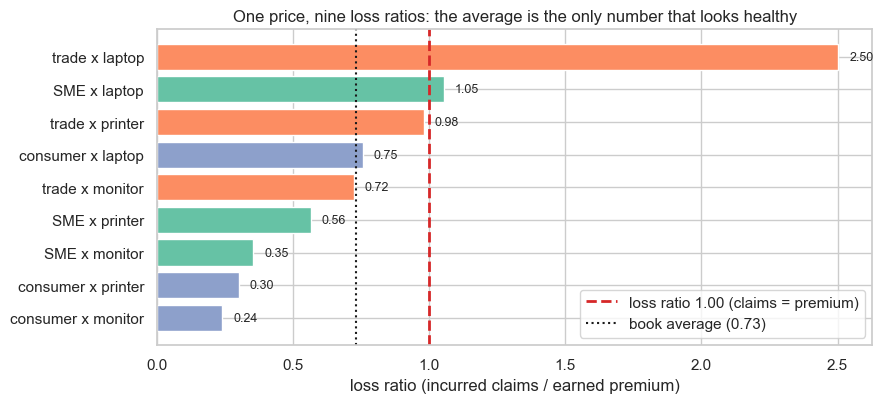

In [4]:
# FIG 1 -- the same book, split nine ways
fig, ax = plt.subplots(figsize=(9, 4.2))
plot_df = by_cell.reset_index().sort_values("loss_ratio")
bars = ax.barh([f"{s} x {d}" for s, d in zip(plot_df.segment, plot_df.device)],
               plot_df.loss_ratio, color=[PALETTE[s] for s in plot_df.segment])
ax.axvline(1.0, color="#d62728", ls="--", lw=2, label="loss ratio 1.00 (claims = premium)")
ax.axvline(LR, color="k", ls=":", lw=1.5, label=f"book average ({LR:.2f})")
for b, v in zip(bars, plot_df.loss_ratio):
    ax.text(v + 0.04, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("loss ratio (incurred claims / earned premium)")
ax.set_title("One price, nine loss ratios: the average is the only number that looks healthy")
ax.legend(loc="lower right")
plt.tight_layout()

The picture is the whole business case: the book average (dotted) sits comfortably left of 1.00, and two bars sit far to its right. Averaging a 0.24 and a 2.50 gives you a number that describes no customer in the portfolio.

Two questions have to be answered before we can price anything, and they are answered in that order because the first one changes the second's inputs. **How often does a plan claim?** — which turns out to be a question about units, not about statistics (§2, §3). **How much does a claim cost?** — which turns out to be a question about which summary statistic you are allowed to trust (§4).

## 2. Exposure — the actuarial version of censoring

Here is the first number an analyst computes, and the first one they get wrong:

$$\text{frequency}_{\text{naive}} = \frac{\text{claims}}{\text{number of plans}}$$

It is wrong for the same reason A5's "average tenure of leavers" was wrong. A5's problem was **censoring** — for two-thirds of the workforce, the thing being measured (time to leaving) *hadn't finished happening*, so any statistic that treated the snapshot as complete was biased in a knowable direction. Insurance has the identical problem wearing a different word. A plan sold in September has been on risk for **four months**, not twelve. It sits in the denominator as one whole plan, but it has only had a third of a year in which to produce a claim. It is an observation that hasn't finished happening.

The fix is to count in **policy-years** — "exposure", or "earned exposure" — instead of policies:

$$\text{frequency}_{\text{earned}} = \frac{\text{claims}}{\sum_i \text{exposure}_i}$$

DeviceCare's book has been growing at ~10 % a month, so it is *young*: most plans in force were written inside the last twelve months. That makes the gap between the two formulas large, and — this is the part that costs money — **it makes it large in the direction of underpricing.**

In [5]:
naive_freq = pol.claims.sum() / len(pol)
earned_freq = pol.claims.sum() / PY

print(f"plans written within the last 12 months : {(pol.months_in_force < 12).mean():.1%}")
print(f"mean exposure                            : {pol.exposure.mean():.3f} policy-years per plan\n")
print(f"naive frequency  (claims / plans)        : {naive_freq:.4f} claims per plan")
print(f"earned frequency (claims / policy-years) : {earned_freq:.4f} claims per policy-YEAR")
print(f"\nthe naive number understates the truth by {1 - naive_freq / earned_freq:.1%};")
print(f"putting it right RAISES the frequency estimate by {earned_freq / naive_freq - 1:.1%}")

by_seg_exp = pol.groupby("segment").agg(plans=("claims", "size"),
                                        policy_years=("exposure", "sum"),
                                        claims=("claims", "sum"))
by_seg_exp["naive"] = by_seg_exp.claims / by_seg_exp.plans
by_seg_exp["earned"] = by_seg_exp.claims / by_seg_exp.policy_years
by_seg_exp["understated_by"] = 1 - by_seg_exp.naive / by_seg_exp.earned
print("\n", by_seg_exp.loc[["consumer", "SME", "trade"]].round(4).to_string())

plans written within the last 12 months : 67.1%
mean exposure                            : 0.611 policy-years per plan

naive frequency  (claims / plans)        : 0.0799 claims per plan
earned frequency (claims / policy-years) : 0.1307 claims per policy-YEAR

the naive number understates the truth by 38.9%;
putting it right RAISES the frequency estimate by 63.6%

           plans  policy_years  claims   naive  earned  understated_by
segment                                                              
consumer  27659    16857.0684    1620  0.0586  0.0961          0.3905
SME       24046    14751.3957    1965  0.0817  0.1332          0.3865
trade      8295     5068.3277    1209  0.1458  0.2385          0.3890


**0.0799 against 0.1307.** The naive frequency understates the real one by **38.9 %** — and since a pure premium is frequency × severity, a rate table built on it prices *every* plan 38.9 % too cheap. On this book that is about **€0.9 m a year of expected claims** that no premium would ever have been collected against — produced by a division that looked like arithmetic.

Two properties of this error are worth naming, because they are what make it dangerous rather than merely wrong:

- **It is a bias, not noise.** More data does not fix it. A book of six million plans growing at 10 % a month has exactly the same 38.9 % gap.
- **It travels.** Here it happens to be nearly uniform across segments (38.7 % – 39.1 %, because all three grew at the same rate), so the *relativities* survive and only the level is wrong. Change one thing — run a promotion that sells trade plans hard in Q4 — and the trade segment's mean exposure drops below everyone else's, the bias becomes *differential*, and your rate table gets the ordering wrong too. Whether exposure corrupts the level or the level *and* the shape depends on facts about your sales calendar that no model can see.

> ⚠️ **The unit is the whole discipline.** "Claims per policy" is not a frequency, in the same way that A5's "47 % of our staff leaves" was not an attrition rate: it has no time in it. Every count model from here on carries exposure explicitly — as an **offset** — and §3 is about how.

---

### ✋ Quick exercise (~2 min) — exposure-weighted frequency by hand

The trade segment: **8,295** plans in force, **5,068.33** policy-years of exposure, **1,209** claims this year.

Compute the naive frequency and the earned frequency, and say by what percentage the naive one understates the truth. Then answer in one line: if the pricing team used the naive number and severity were estimated correctly, how far off would the trade pure premium be?

In [6]:
# ✍️ Your turn 👇
plans_trade, policy_years_trade, claims_trade = 8_295, 5_068.33, 1_209

# naive_t  = claims / plans
# earned_t = claims / policy-years
# understatement = 1 - naive_t / earned_t

<details>
<summary>✅ <b>Solution</b></summary>

```python
plans_trade, policy_years_trade, claims_trade = 8_295, 5_068.33, 1_209
naive_t = claims_trade / plans_trade
earned_t = claims_trade / policy_years_trade
print(f"naive  : {naive_t:.4f} claims per plan")
print(f"earned : {earned_t:.4f} claims per policy-year")
print(f"the naive figure understates frequency by {1 - naive_t / earned_t:.1%}")
print(f"-> the trade pure premium would come out {1 - naive_t / earned_t:.1%} too low, "
      f"and so would its price")
```

**0.1458 vs 0.2385 — the naive figure is 38.9 % low.** Because the pure premium is frequency × severity and only the frequency is wrong, the error passes through untouched: a trade pure premium of €140 would be quoted as €86. The mistake never announces itself, because both numbers are perfectly reasonable-looking claim rates. The only thing that betrays it is the *unit*, which is why actuarial tables always carry an exposure column next to the claim count — it is the one convention that makes this class of error impossible to commit silently.
</details>

## 3. Frequency: a Poisson GLM with an offset

Counts want a Poisson model. But the quantity we want to model is a **rate** $\lambda_i$ — claims per policy-year — while the quantity we *observe* is a count $y_i$ produced over $e_i$ policy-years. The two are linked by

$$y_i \sim \text{Poisson}(\lambda_i \, e_i), \qquad \log(\lambda_i e_i) = \log e_i + \mathbf{x}_i^\top \boldsymbol\beta$$

That $\log e_i$ term is an **offset**: a predictor whose coefficient is *fixed at 1* rather than estimated. It is not a feature. It is a unit conversion, baked into the linear predictor, and it is what turns a count model into a rate model. In `statsmodels` it is one keyword — `offset=np.log(exposure)` — and 🧪 Exercise 3 is the price of forgetting it.

The log link is the other half of the actuarial convention: it makes the rate **multiplicative**, so each rating factor contributes a *relativity* — "laptops claim 1.9× as often as monitors" — which is exactly the form a rate table needs and exactly the form a committee can argue about. We model frequency on device, segment, channel, district and declared usage, and — because we planted the truth — we can check every relativity against it.

In [7]:
pol["usage_c"] = pol.usage - USAGE_REF                 # centre usage on 5 h/day
pol["log_exposure"] = np.log(pol.exposure)             # the offset

FREQ_FORMULA = ("claims ~ C(device, Treatment('monitor')) + C(segment, Treatment('consumer')) "
                "+ C(channel, Treatment('webshop')) + C(district, Treatment('suburban')) + usage_c")

freq_glm = smf.glm(FREQ_FORMULA, data=pol, family=sm.families.Poisson(),
                   offset=pol.log_exposure).fit()

planted = {
    "Intercept": FREQ_BASE * FREQ_DEVICE["monitor"] * FREQ_DISTRICT["suburban"],
    "C(device, Treatment('monitor'))[T.laptop]": FREQ_DEVICE["laptop"] / FREQ_DEVICE["monitor"],
    "C(device, Treatment('monitor'))[T.printer]": FREQ_DEVICE["printer"] / FREQ_DEVICE["monitor"],
    "C(segment, Treatment('consumer'))[T.SME]": FREQ_SEGMENT["SME"],
    "C(segment, Treatment('consumer'))[T.trade]": FREQ_SEGMENT["trade"],
    "C(channel, Treatment('webshop'))[T.reseller]": FREQ_CHANNEL["reseller"],
    "C(channel, Treatment('webshop'))[T.telesales]": FREQ_CHANNEL["telesales"],
    "C(district, Treatment('suburban'))[T.inner city]": FREQ_DISTRICT["inner city"] / FREQ_DISTRICT["suburban"],
    "C(district, Treatment('suburban'))[T.rural]": FREQ_DISTRICT["rural"] / FREQ_DISTRICT["suburban"],
    "usage_c": np.exp(FREQ_USAGE),
}
NICE = {"Intercept": "base rate: monitor/consumer/webshop/suburban, 5 h/day",
        "C(device, Treatment('monitor'))[T.laptop]": "device: laptop",
        "C(device, Treatment('monitor'))[T.printer]": "device: printer",
        "C(segment, Treatment('consumer'))[T.SME]": "segment: SME",
        "C(segment, Treatment('consumer'))[T.trade]": "segment: trade",
        "C(channel, Treatment('webshop'))[T.reseller]": "channel: reseller",
        "C(channel, Treatment('webshop'))[T.telesales]": "channel: telesales",
        "C(district, Treatment('suburban'))[T.inner city]": "district: inner city",
        "C(district, Treatment('suburban'))[T.rural]": "district: rural",
        "usage_c": "usage: per +1 h/day"}

ci = freq_glm.conf_int()
recovery = pd.DataFrame({"relativity": np.exp(freq_glm.params), "planted truth": pd.Series(planted),
                         "ci_lo": np.exp(ci[0]), "ci_hi": np.exp(ci[1])})
recovery["truth in CI?"] = np.where(
    (recovery["planted truth"] >= recovery.ci_lo) & (recovery["planted truth"] <= recovery.ci_hi), "yes", "NO")
recovery.index = [NICE[i] for i in recovery.index]
print(recovery.round(3).to_string())

                                                       relativity  planted truth  ci_lo  ci_hi truth in CI?
base rate: monitor/consumer/webshop/suburban, 5 h/day       0.065          0.064  0.059  0.071          yes
device: laptop                                              1.887          1.857  1.758  2.026          yes
device: printer                                             1.469          1.429  1.348  1.601          yes
segment: SME                                                1.213          1.220  1.132  1.299          yes
segment: trade                                              1.690          1.750  1.539  1.856          yes
channel: reseller                                           1.077          1.050  1.010  1.149          yes
channel: telesales                                          1.215          1.180  1.123  1.315          yes
district: inner city                                        1.226          1.250  1.152  1.305          yes
district: rural             

Every planted relativity is inside its 95 % interval, and most are within a few percent of the point estimate. Read the table as a rate table in waiting:

- **A laptop claims 1.89× as often as a monitor** (planted 1.86) and a printer 1.47× (1.43). Portability and moving parts, priced.
- **Trade customers claim 1.69× as often as consumers** (planted 1.75), SMEs 1.21× (1.22) — *after* controlling for device and usage, so this is not "trade buys more laptops"; it is trade using the same laptop harder in a worse environment.
- **Every extra hour a day of declared use multiplies the rate by 1.098** (planted 1.094). Over the consumer-to-trade usage gap of ~4 hours that is a 1.44× factor on its own.
- **Inner city 1.23× rural 0.80×** — theft and knocks, geographically. Note this is a property of *where the device lives*, which is why it is a defensible rating factor and `credit_band` (§6) is not.
- The base rate — a suburban consumer's webshop-bought monitor at 5 h/day — is **0.065 claims per policy-year**: one claim every fifteen years.

Two things this model already did that the naive analysis could not. It read the frequency **per policy-year**, so all of these are annual rates you can quote on a three-year plan. And it estimated every factor **holding the others fixed**, which matters wherever rating factors move together: `usage` and `segment` do here (trade customers declare 7.5 h/day against consumers' 3.5), so a raw "trade claims 2.5× as often" table would be charging trade twice — once for being trade and once for the hours that come with it. The 1.69× is what survives that separation, and separability is the only form in which a rate table can be audited.

### 🔮 Predict the output

The Poisson distribution has one parameter and therefore one very strong opinion: **variance = mean**. If it is right, then inside a group of genuinely identical policies the claim counts should scatter no more than Poisson noise.

We have such a group: **trade × laptop plans with a full year of exposure** — 1,225 of them, same device, same segment, same 12 months on risk. Their mean claim count is **0.286**.

Before running the cell: what do you expect the **variance** of those 1,225 counts to be? Equal to 0.286, as Poisson insists? And what would it mean for the table you just read if it isn't?

In [8]:
cell = pol[(pol.segment == "trade") & (pol.device == "laptop") & (pol.exposure == 1.0)]
print(f"trade x laptop, full-year exposure: n = {len(cell):,}")
print(f"  mean count     : {cell.claims.mean():.3f}")
print(f"  variance       : {cell.claims.var():.3f}")
print(f"  variance / mean: {cell.claims.var() / cell.claims.mean():.2f}   <- Poisson says 1.00")
print(f"  counts observed: {cell.claims.value_counts().sort_index().to_dict()}")

phi = freq_glm.pearson_chi2 / freq_glm.df_resid
print(f"\nmodel-wide dispersion  (Pearson chi2 / df) = {phi:.3f}")
alpha_hat = (phi - 1) / freq_glm.fittedvalues.mean()
print(f"method-of-moments negative-binomial alpha  = {alpha_hat:.3f} "
      f"(planted heterogeneity variance {1 / FRAILTY_SHAPE:.3f})")

trade x laptop, full-year exposure: n = 1,225
  mean count     : 0.286
  variance       : 0.574
  variance / mean: 2.01   <- Poisson says 1.00
  counts observed: {0: 994, 1: 161, 2: 46, 3: 14, 4: 4, 5: 2, 6: 2, 8: 1, 9: 1}

model-wide dispersion  (Pearson chi2 / df) = 1.225
method-of-moments negative-binomial alpha  = 2.820 (planted heterogeneity variance 2.857)


**Variance 0.574 against a mean of 0.286 — a ratio of 2.01.** Poisson is out by a factor of two inside a cell it was supposed to describe exactly. Look at the count distribution: 994 of those 1,225 plans claimed nothing all year, and one of them claimed **nine times**. Poisson at $\lambda = 0.286$ would produce a nine roughly once in a hundred billion policies.

The cause is not exotic and it is not a modelling mistake — it is the thing every rating factor list is missing. Two trade laptops with identical paperwork are not identical: one lives in a padded case, one lives in a van footwell. That unmeasured heterogeneity (the generator's `frailty`, and in your data the columns nobody collected) makes the claim rate itself random, and a Poisson with a random rate is a **negative binomial**. The method-of-moments estimate recovers the planted spread almost exactly: **α = 2.82** against a planted 2.86.

Now the part that matters for decisions. Overdispersion damages **one** of the two things a GLM gives you:

In [9]:
nb_glm = smf.glm(FREQ_FORMULA, data=pol,
                 family=sm.families.NegativeBinomial(alpha=alpha_hat),
                 offset=pol.log_exposure).fit()

compare = pd.DataFrame({"Poisson relativity": np.exp(freq_glm.params), "Poisson se": freq_glm.bse,
                        "NegBin relativity": np.exp(nb_glm.params), "NegBin se": nb_glm.bse})
compare["se widened by"] = compare["NegBin se"] / compare["Poisson se"]
compare.index = [NICE[i] for i in compare.index]
print(compare.round(4).to_string())

key = "C(segment, Treatment('consumer'))[T.trade]"
lo_p, hi_p = np.exp(freq_glm.conf_int().loc[key])
lo_n, hi_n = np.exp(nb_glm.conf_int().loc[key])
print(f"\ntrade relativity {np.exp(freq_glm.params[key]):.3f}")
print(f"  Poisson 95% CI [{lo_p:.3f}, {hi_p:.3f}]")
print(f"  NegBin  95% CI [{lo_n:.3f}, {hi_n:.3f}]   ({(hi_n - lo_n) / (hi_p - lo_p):.2f}x wider)")

                                                       Poisson relativity  Poisson se  NegBin relativity  NegBin se  se widened by
base rate: monitor/consumer/webshop/suburban, 5 h/day              0.0648      0.0445             0.0653     0.0498         1.1190
device: laptop                                                     1.8874      0.0362             1.8898     0.0409         1.1282
device: printer                                                    1.4693      0.0439             1.4574     0.0496         1.1292
segment: SME                                                       1.2125      0.0350             1.2053     0.0396         1.1319
segment: trade                                                     1.6897      0.0478             1.6949     0.0560         1.1714
channel: reseller                                                  1.0770      0.0329             1.0660     0.0381         1.1583
channel: telesales                                                 1.2150      0.04

The relativities barely move — trade goes from **1.6897 to 1.6949**, a change of three parts in a thousand — while every standard error grows by **12 % to 18 %**. That asymmetry is the lesson, and it generalises well beyond insurance:

> ⚠️ **Overdispersion is an honesty problem, not an accuracy problem.** The Poisson mean structure is still consistent when the variance assumption fails, so your *rates* survive. What does not survive is your *certainty about them*: the Poisson standard errors are computed from a variance that is only half the real one, so every interval is too narrow, every p-value too small, and every "this factor is significant" too confident. If you price off the point estimates you are fine. The moment you use the model to decide whether a factor **earns its place in the rate table** — a hypothesis test — the Poisson version will admit factors that are noise.

For DeviceCare this is not academic. The trade relativity's honest interval is **[1.52, 1.89]**, and the difference between charging a trade customer 1.5× and 1.9× the base rate is the difference between keeping and losing that channel. Report the negative-binomial interval; price off either point estimate.

---

### ✋ Quick exercise (~2 min) — read a dispersion statistic

A colleague fits a Poisson frequency GLM to a different product line and reports: *Pearson χ² / df = 1.96, and the strongest new rating factor has a Poisson p-value of 0.031, so we're adding it to the table.*

Using only those two numbers: **(a)** what does 1.96 say about the variance of the counts? **(b)** roughly how much wider should the factor's standard error be? **(c)** what happens to a z-statistic of 2.16 (which is what p = 0.031 corresponds to) once you widen it — does the factor still clear the usual 5 % bar?

In [10]:
# ✍️ Your turn 👇
dispersion, z_reported = 1.96, 2.16

# (a) variance is `dispersion` times the mean
# (b) standard errors scale with sqrt(dispersion)   -> se_honest = se_poisson * sqrt(dispersion)
# (c) z_honest = z_reported / sqrt(dispersion) ; compare with 1.96

<details>
<summary>✅ <b>Solution</b></summary>

```python
dispersion, z_reported = 1.96, 2.16
inflation = np.sqrt(dispersion)
z_honest = z_reported / inflation
print(f"(a) the counts vary {dispersion:.2f}x as much as Poisson allows")
print(f"(b) standard errors should be {inflation:.2f}x wider")
print(f"(c) z {z_reported:.2f} -> {z_honest:.2f}; clears 1.96? {'yes' if abs(z_honest) > 1.96 else 'NO'}")
```

Variance is nearly **double** the mean, so the honest standard errors are **√1.96 = 1.40×** wider and the z-statistic falls from 2.16 to **1.54** — comfortably *inside* the noise band. The factor does not clear the bar; it only appeared to because the model was asked to believe a variance assumption the data had already refused. This is the quasi-Poisson correction in one line (`fit(scale="X2")` in `statsmodels` does exactly this to the standard errors), and it is the cheapest reality check available on any count model. Note what it does *not* change: the factor's estimated relativity is untouched. Overdispersion never told you the effect was wrong — only that you could not yet tell it from zero.
</details>

## 4. Severity, and why the mean is a bad summary

Frequency answers *how often*. Severity answers *how much*, and it is where a rate table gets destroyed by a summary statistic that everyone trusts.

In [11]:
print(f"claims: {len(clm):,}")
print(f"  mean   EUR {clm.amount.mean():>9,.0f}")
print(f"  median EUR {clm.amount.median():>9,.0f}")
print(f"  p75    EUR {clm.amount.quantile(0.75):>9,.0f}")
print(f"  p95    EUR {clm.amount.quantile(0.95):>9,.0f}")
print(f"  p99    EUR {clm.amount.quantile(0.99):>9,.0f}")
print(f"  max    EUR {clm.amount.max():>9,.0f}")
print(f"\nshare of claims ABOVE the mean : {(clm.amount > clm.amount.mean()).mean():.1%}")
print(f"top 1% of claims  = {clm.amount.nlargest(len(clm) // 100).sum() / clm.amount.sum():.1%} of all incurred")
print(f"top 10 claims     = EUR {clm.amount.nlargest(10).sum():,.0f} = "
      f"{clm.amount.nlargest(10).sum() / clm.amount.sum():.1%} of all incurred")
print("\nthe five that move the rate table:")
print(clm.nlargest(5, "amount").to_string(index=False))

claims: 4,794
  mean   EUR       497
  median EUR       269
  p75    EUR       532
  p95    EUR     1,490
  p99    EUR     3,232
  max    EUR    25,953

share of claims ABOVE the mean : 27.6%
top 1% of claims  = 17.1% of all incurred
top 10 claims     = EUR 198,550 = 8.3% of all incurred

the five that move the rate table:
 policy  device  segment         cause   amount
  44474  laptop    trade theft (fleet) 25952.67
  54727 monitor      SME theft (fleet) 25946.34
  14143  laptop    trade  batch defect 24143.78
  42578  laptop consumer theft (fleet) 20561.73
   6736  laptop      SME theft (fleet) 20492.96


The mean claim is **€497**. The median is **€269**. Only **27.6 %** of claims are bigger than the mean — the average is not a typical claim, it is a typical claim *plus the tail's rent*. And the tail is not decoration: the **top 1 % of claims carries 17.1 %** of everything paid out, and ten claims out of 4,794 carry **8.3 %**.

Look at what those ten are. A stolen trade laptop bundle at **€25,953**. A batch of SME monitors lifted from a van at €25,946. A printer firmware defect that took out a whole floor. These are not laptops with cracked screens; they are *different events* that happen to be booked on the same claim form. Which raises the question that all of severity modelling turns on:

> **Which cell of the rate table should pay for the €25,953 theft?**

The naive answer — "trade × laptop, that's where it happened" — is how a rate table gets written by a coin flip. That single claim is worth **€11.40 per policy-year** spread across trade × laptop's 2,277 policy-years. Had the van been parked in a different postcode it would have landed in a different cell and moved a *different* rate by the same amount. You would be rating on where lightning struck, not on where it strikes.

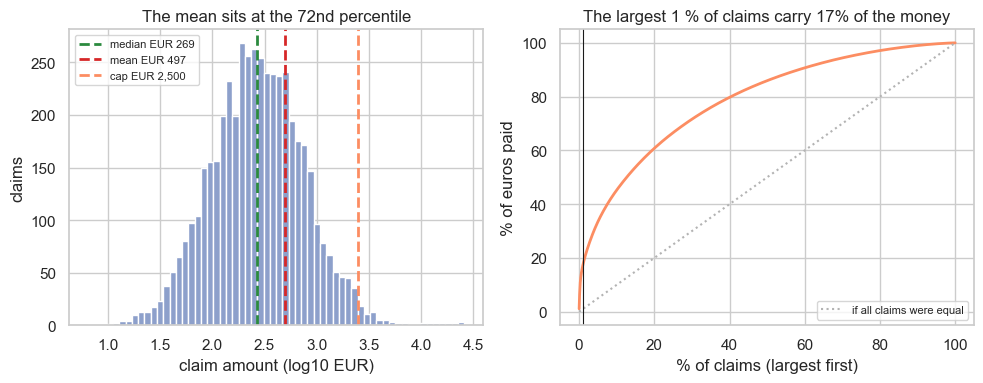

In [12]:
# FIG 2 -- the shape of the problem
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(np.log10(clm.amount), bins=60, color="#8da0cb", edgecolor="white")
for x, lab, col in [(clm.amount.median(), f"median EUR {clm.amount.median():,.0f}", "#2b8a3e"),
                    (clm.amount.mean(), f"mean EUR {clm.amount.mean():,.0f}", "#d62728"),
                    (LARGE_LOSS_CAP, f"cap EUR {LARGE_LOSS_CAP:,.0f}", "#fc8d62")]:
    axes[0].axvline(np.log10(x), color=col, ls="--", lw=2, label=lab)
axes[0].set_xlabel("claim amount (log10 EUR)")
axes[0].set_ylabel("claims")
axes[0].set_title("The mean sits at the 72nd percentile")
axes[0].legend(fontsize=8)

srt = np.sort(clm.amount)[::-1]
share_claims = np.arange(1, len(srt) + 1) / len(srt)
share_euros = np.cumsum(srt) / srt.sum()
axes[1].plot(share_claims * 100, share_euros * 100, color="#fc8d62", lw=2)
axes[1].plot([0, 100], [0, 100], color="#b3b3b3", ls=":", lw=1.5, label="if all claims were equal")
axes[1].axvline(1, color="k", lw=0.8)
axes[1].set_xlabel("% of claims (largest first)")
axes[1].set_ylabel("% of euros paid")
axes[1].set_title(f"The largest 1 % of claims carry {share_euros[len(srt) // 100 - 1]:.0%} of the money")
axes[1].legend(fontsize=8)
plt.tight_layout()

The standard answer to "who pays for the €25,953" is **large-loss capping**. You split every claim in two at a threshold:

- the **working layer**, everything up to the cap, which is frequent enough to be *credible* inside each rating cell — that is what the cell's own experience gets to price;
- the **excess layer**, everything above the cap, which is rare, volatile and essentially unattributable — so it is pooled across the whole book and charged as one flat **large-loss load** on every policy-year.

We fit the severity model on capped amounts with a **Gamma GLM and a log link** — Gamma because claim amounts are positive, right-skewed and have variance that grows with the mean; log link for the same multiplicative-relativity reason as frequency.

In [13]:
clm["capped"] = clm.amount.clip(upper=LARGE_LOSS_CAP)
excess_total = (clm.amount - clm.capped).sum()
excess_load = excess_total / PY                    # EUR per policy-year, charged to everyone

print(f"claims piercing the EUR {LARGE_LOSS_CAP:,.0f} cap : "
      f"{(clm.amount > LARGE_LOSS_CAP).sum()} ({(clm.amount > LARGE_LOSS_CAP).mean():.2%} of claims)")
print(f"mean severity, capped               : EUR {clm.capped.mean():.0f}  "
      f"(uncapped EUR {clm.amount.mean():.0f}, {clm.capped.mean() / clm.amount.mean() - 1:+.1%})")
print(f"excess above the cap                : EUR {excess_total:,.0f} = "
      f"{excess_total / pol.incurred.sum():.1%} of everything incurred")
print(f"LARGE-LOSS LOAD                     : EUR {excess_load:.2f} per policy-year, on every plan")

SEV_FORMULA = "capped ~ C(device, Treatment('monitor')) + C(segment, Treatment('consumer'))"
sev_glm = smf.glm(SEV_FORMULA, data=clm, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
sev_uncapped = smf.glm(SEV_FORMULA.replace("capped ~", "amount ~"), data=clm,
                       family=sm.families.Gamma(link=sm.families.links.Log())).fit()

sev_table = pd.DataFrame({"capped model": np.exp(sev_glm.params), "se": sev_glm.bse,
                          "uncapped model": np.exp(sev_uncapped.params), "se ": sev_uncapped.bse})
sev_table.index = ["base severity (monitor/consumer), EUR", "device: laptop", "device: printer",
                   "segment: SME", "segment: trade"]
print("\n", sev_table.round(3).to_string())

claims piercing the EUR 2,500 cap : 74 (1.54% of claims)
mean severity, capped               : EUR 434  (uncapped EUR 497, -12.5%)
excess above the cap                : EUR 297,762 = 12.5% of everything incurred
LARGE-LOSS LOAD                     : EUR 8.12 per policy-year, on every plan



                                        capped model     se  uncapped model    se 
base severity (monitor/consumer), EUR       279.911  0.039         324.441  0.083
device: laptop                                1.771  0.039           1.677  0.082
device: printer                               1.084  0.047           0.967  0.100
segment: SME                                  1.082  0.036           1.087  0.076
segment: trade                                1.133  0.041           1.301  0.086


Compare the two columns and you can watch a rate table being written by a single van theft.

On **capped** severities, a laptop claim costs **1.77×** a monitor claim and a trade claim **1.13×** a consumer one — stable, sensible, estimated from 4,794 claims each of which is at most €2,500. On **uncapped** severities the laptop relativity *falls* to 1.68 while the trade relativity *jumps* to 1.30, and every standard error roughly doubles (0.041 → 0.086 for trade). The uncapped model is not seeing more signal; it is being shoved around by seventy-four claims, and one of those seventy-four is worth 10,000 monitor repairs.

Note what capping did to the *total*, though — and this is the sentence that keeps a capped rate table honest:

> ⚠️ **A cap does not delete a loss. It moves it.** The €297,762 above €2,500 did not stop being owed the moment we clipped the column; it came straight back as **€8.12 per policy-year** charged to all 36,677 policy-years, including the consumer monitors that will never see a €25,000 claim. That is a deliberate, defensible choice — the tail is a portfolio-level risk, so the portfolio pays for it — but it is a *choice*, and it is the same choice a real insurer makes when it buys **excess-of-loss reinsurance**: the reinsurer takes the layer above the cap, and the premium it charges is this load plus its own margin. Cap without adding the load back and you have simply lost 12.5 % of your claims cost.

§5 assembles both halves into the price, and 🧪 Exercise 2 turns the cap into a dial so you can watch where the money goes.

---

### ✋ Quick exercise (~2 min) — a pure premium by hand

For **SME × laptop** the fitted models give an annual frequency of **0.167** claims per policy-year and a capped severity of **€536.14**, and the book-wide large-loss load is **€8.12** per policy-year.

Compute (a) the pure premium, (b) the technical price using `(pure premium + EXP_FIX) / LOAD_DIV`, and (c) the gap against today's €89. Then say in one line what that gap means for the 6,647 policy-years in that cell.

In [14]:
# ✍️ Your turn 👇
freq_sme_laptop, sev_sme_laptop, load = 0.167, 536.14, 8.12

# pure_premium = frequency * severity + large-loss load
# technical    = (pure_premium + EXP_FIX) / LOAD_DIV
# gap          = technical - PRICE_FLAT ... times 6_647 policy-years

<details>
<summary>✅ <b>Solution</b></summary>

```python
freq_sme_laptop, sev_sme_laptop, load = 0.167, 536.14, 8.12
pp_sme_laptop = freq_sme_laptop * sev_sme_laptop + load
tech_sme_laptop = (pp_sme_laptop + EXP_FIX) / LOAD_DIV
print(f"pure premium   : EUR {pp_sme_laptop:.2f} per policy-year")
print(f"technical price: EUR {tech_sme_laptop:.2f}   (charged today: EUR {PRICE_FLAT:.2f})")
print(f"shortfall      : EUR {tech_sme_laptop - PRICE_FLAT:.2f}/policy-year "
      f"= EUR {(tech_sme_laptop - PRICE_FLAT) * 6_647:,.0f}/yr across the cell")
```

Pure premium **€97.66**, technical price **€131.44** — the cell should cost roughly **€131** and is being sold for €89. That is a **€42.44** shortfall per policy-year and **€282,127 a year** across SME × laptop alone, which is nearly twice the entire book's underwriting margin of €151,832. Notice the arithmetic of the loading: the €7.50 fixed expense and the 20 % divisor together turn €97.66 of expected claims into €131.44 of price — on a small pure premium the loading is proportionally *enormous* (consumer × monitor's €26 of claims becomes €42), which is why cheap insurance is expensive insurance and why minimum premiums exist.
</details>

## 5. The technical price and the cross-subsidy

Everything is now in place. For each policy:

$$\underbrace{\text{pure premium}}_{\text{expected loss / policy-year}} = \underbrace{\hat\lambda(\mathbf{x})}_{\text{§3, per policy-year}} \times \underbrace{\hat{s}(\mathbf{x})}_{\text{§4, capped}} \;+\; \underbrace{L}_{\text{large-loss load}}$$

$$\text{technical price} = \frac{\text{pure premium} + \text{fixed expense}}{1 - \text{variable expense} - \text{capital load}}$$

The denominator is doing real work: **€0.14 of every premium euro** leaves as commission and acquisition cost and **€0.06** is the return the capital backing this book has to earn, so the pure premium and the fixed €7.50 have to be covered by the remaining €0.80. That is where the "technical price" name comes from — it is the price at which the product is *technically* neutral: no profit beyond the capital charge, no subsidy from anywhere else.

In [15]:
pol["freq_hat"] = freq_glm.predict(pol, offset=np.zeros(len(pol)))   # ANNUAL rate: offset 0 = 1 year
pol["sev_hat"] = sev_glm.predict(pol)
pol["sev_uncapped_hat"] = sev_uncapped.predict(pol)
pol["pure_prem"] = pol.freq_hat * pol.sev_hat + excess_load
pol["technical"] = (pol.pure_prem + EXP_FIX) / LOAD_DIV
pol["technical_uncapped"] = (pol.freq_hat * pol.sev_uncapped_hat + EXP_FIX) / LOAD_DIV

print(f"modelled pure premium, exposure-weighted : EUR {np.average(pol.pure_prem, weights=pol.exposure):.2f}")
print(f"empirical pure premium (incurred / PY)   : EUR {pol.incurred.sum() / PY:.2f}   <- the model balances")
print(f"\nbook-average TECHNICAL price             : EUR {np.average(pol.technical, weights=pol.exposure):.2f}")
print(f"today's flat price                       : EUR {PRICE_FLAT:.2f}")
print("-> the flat price is within EUR 1.50 of being right ON AVERAGE. That is why nobody noticed.")

modelled pure premium, exposure-weighted : EUR 64.90
empirical pure premium (incurred / PY)   : EUR 64.90   <- the model balances

book-average TECHNICAL price             : EUR 90.50
today's flat price                       : EUR 89.00
-> the flat price is within EUR 1.50 of being right ON AVERAGE. That is why nobody noticed.


In [16]:
rate_table = (pol.groupby(["segment", "device"])
                 .apply(lambda g: pd.Series({
                     "policy_years": g.exposure.sum(),
                     "frequency": np.average(g.freq_hat, weights=g.exposure),
                     "severity": np.average(g.sev_hat, weights=g.exposure),
                     "pure_prem": np.average(g.pure_prem, weights=g.exposure),
                     "technical": np.average(g.technical, weights=g.exposure),
                     "tech_uncapped": np.average(g.technical_uncapped, weights=g.exposure),
                 }), include_groups=False)
                 .reset_index())
rate_table["loss_ratio_now"] = by_cell.loss_ratio.reindex(
    pd.MultiIndex.from_arrays([rate_table.segment, rate_table.device])).to_numpy()
rate_table["gap_vs_89"] = PRICE_FLAT - rate_table.technical
rate_table["book_gap"] = rate_table.gap_vs_89 * rate_table.policy_years
rate_table = rate_table.sort_values("technical").reset_index(drop=True)

print(rate_table[["segment", "device", "policy_years", "frequency", "severity",
                  "pure_prem", "technical", "loss_ratio_now"]].round(3).to_string(index=False))

 segment  device  policy_years  frequency  severity  pure_prem  technical  loss_ratio_now
consumer monitor      5579.246      0.064   279.911     26.002     41.878           0.240
     SME monitor      4857.411      0.089   302.813     35.032     53.164           0.353
consumer printer      3623.329      0.094   303.440     36.699     55.249           0.299
     SME printer      3246.662      0.130   328.266     50.793     72.866           0.564
   trade monitor      1694.498      0.159   317.185     58.626     82.657           0.722
consumer  laptop      7654.494      0.120   495.588     67.830     94.162           0.755
   trade printer      1097.164      0.234   343.846     88.556    120.070           0.979
     SME  laptop      6647.322      0.167   536.136     97.744    131.555           1.053
   trade  laptop      2276.665      0.300   561.582    176.473    229.966           2.503


There is the product, priced. It runs from **€41.88** for a consumer's monitor to **€229.97** for a trade laptop — a **5.5× spread** inside a single €89 SKU. Sanity-check it against the last column: the cells whose technical price is far above €89 are exactly the cells whose loss ratio is already above 1.00, which is what it looks like when a model and a spreadsheet agree.

The cap's fingerprints are visible if you compare the two technical columns:

In [17]:
cap_effect = rate_table[["segment", "device", "policy_years", "technical", "tech_uncapped"]].copy()
cap_effect["moved_by"] = cap_effect.technical - cap_effect.tech_uncapped
print(cap_effect.round(2).to_string(index=False))
print(f"\nbook-average technical, capped + load : EUR {np.average(pol.technical, weights=pol.exposure):.2f}")
print(f"book-average technical, uncapped      : EUR {np.average(pol.technical_uncapped, weights=pol.exposure):.2f}")
print("-> same total, different allocation. The cap is a redistribution rule, not a discount.")

 segment  device  policy_years  technical  tech_uncapped  moved_by
consumer monitor       5579.25      41.88          35.29      6.59
     SME monitor       4857.41      53.16          48.56      4.61
consumer printer       3623.33      55.25          46.31      8.94
     SME printer       3246.66      72.87          64.80      8.07
   trade monitor       1694.50      82.66          93.37    -10.71
consumer  laptop       7654.49      94.16          91.30      2.87
   trade printer       1097.16     120.07         128.70     -8.63
     SME  laptop       6647.32     131.56         132.94     -1.38
   trade  laptop       2276.67     229.97         274.50    -44.53

book-average technical, capped + load : EUR 90.50
book-average technical, uncapped      : EUR 90.46
-> same total, different allocation. The cap is a redistribution rule, not a discount.


**€90.50 either way.** Capping moved **€44.53 a year off** the trade laptop rate and put **€6.59 onto** the consumer monitor rate, and collected the same total premium. That is the entire economics of a cap in two numbers: it is a decision about *who pays for the tail*, made before you know where the tail will fall. Charge trade × laptop the uncapped €274.50 and you are billing them for a van theft that could as easily have happened to an SME; charge them €229.97 and every plan in the book chips in €8.12 towards the next one.

Now the number the product committee actually needs — what the flat price is doing to each cell, in euros.

 segment  device  policy_years  technical  gap_vs_89   book_gap        role
consumer monitor       5579.25      41.88      47.12  262905.00 SUBSIDISING
     SME monitor       4857.41      53.16      35.84  174068.15 SUBSIDISING
consumer printer       3623.33      55.25      33.75  122291.66 SUBSIDISING
     SME printer       3246.66      72.87      16.13   52382.16 SUBSIDISING
   trade monitor       1694.50      82.66       6.34   10748.06 SUBSIDISING
consumer  laptop       7654.49      94.16      -5.16  -39515.86  subsidised
   trade printer       1097.16     120.07     -31.07  -34088.37  subsidised
     SME  laptop       6647.32     131.56     -42.56 -282877.41  subsidised
   trade  laptop       2276.67     229.97    -140.97 -320932.99  subsidised

over-charged cells hand over : EUR 622,395 per year
under-charged cells receive  : EUR 677,415 per year
gross cross-subsidy          : EUR 1,299,810 per year = 39.8% of earned premium


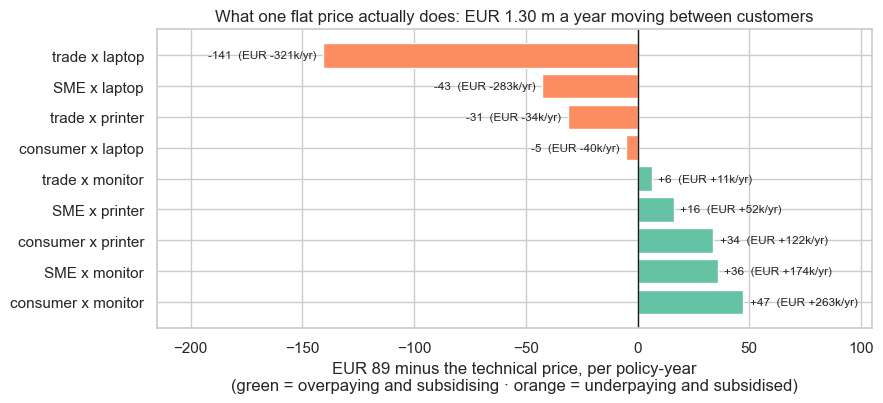

In [18]:
subsidy = rate_table[["segment", "device", "policy_years", "technical", "gap_vs_89", "book_gap"]].copy()
subsidy["role"] = np.where(subsidy.gap_vs_89 > 0, "SUBSIDISING", "subsidised")
print(subsidy.round(2).to_string(index=False))

pays_in = subsidy.loc[subsidy.gap_vs_89 > 0, "book_gap"].sum()
takes_out = -subsidy.loc[subsidy.gap_vs_89 < 0, "book_gap"].sum()
print(f"\nover-charged cells hand over : EUR {pays_in:,.0f} per year")
print(f"under-charged cells receive  : EUR {takes_out:,.0f} per year")
print(f"gross cross-subsidy          : EUR {pays_in + takes_out:,.0f} per year = "
      f"{(pays_in + takes_out) / pol.earned.sum():.1%} of earned premium")

# FIG 3 -- the cross-subsidy, in euros per policy-year
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = [f"{s} x {d}" for s, d in zip(subsidy.segment, subsidy.device)]
colours = ["#66c2a5" if g > 0 else "#fc8d62" for g in subsidy.gap_vs_89]
ax.barh(labels, subsidy.gap_vs_89, color=colours)
ax.axvline(0, color="k", lw=1)
for i, (g, bg) in enumerate(zip(subsidy.gap_vs_89, subsidy.book_gap)):
    ax.text(g + (3 if g > 0 else -3), i, f"{g:+.0f}  (EUR {bg / 1000:+,.0f}k/yr)",
            va="center", ha="left" if g > 0 else "right", fontsize=8.5)
ax.set_xlim(-215, 105)
ax.set_xlabel("EUR 89 minus the technical price, per policy-year\n"
              "(green = overpaying and subsidising · orange = underpaying and subsidised)")
ax.set_title("What one flat price actually does: EUR 1.30 m a year moving between customers")
plt.tight_layout()

**€1,299,810 a year** — 39.8 % of the earned premium — is being moved between customers who have never met. Read the extremes:

- A **consumer with a monitor** pays €89 for €41.88 of product. They are being charged **more than twice** what their risk costs, and there are 5,579 policy-years of them handing over **€262,905 a year**.
- A **trade customer with a laptop** pays €89 for €229.97 of product. Each one is subsidised by **€140.97 a year**; the cell absorbs **€320,933 a year** from the rest of the book.

Two honest caveats before anyone reprices anything. First, cross-subsidy is not itself a scandal — every insurance pool is a cross-subsidy, that is what pooling *means*, and the whole product would be pointless if each customer paid exactly their own loss. What is being priced here is **systematic, predictable** subsidy between *identifiable groups*, which is a different animal from the random subsidy between the unlucky and the lucky. Second, the rate table is an estimate; 🧠 Stretch C bootstraps it and finds that several of these cells are not statistically distinguishable from one another, which is an argument for a *coarser* table, not for the flat one.

Because the flat price is not stable. It is only stable as long as nobody offers the consumer with the monitor a better deal.

---

### ✋ Quick exercise (~2 min) — read one cross-subsidy row

The **consumer × monitor** row: technical price **€41.88**, charged €89, **5,579.25** policy-years in the cell.

**(a)** Confirm the ≈ €263 k contribution shown in the table above. **(b)** A competitor launches a monitor-only plan at **€55** — comfortably above the €41.88 technical price, so profitable for them. What share of this cell's subsidy contribution survives if they take those customers, and what does the webshop's book-wide loss ratio do?

In [19]:
# ✍️ Your turn 👇
tech_cons_monitor, py_cons_monitor = 41.88, 5_579.25
competitor_price = 55.0

# (a) (PRICE_FLAT - tech) * policy_years
# (b) if they all leave: the webshop loses that premium AND the claims. Recompute the
#     book loss ratio without this cell -- use by_cell.loc[("consumer", "monitor")]

<details>
<summary>✅ <b>Solution</b></summary>

```python
tech_cons_monitor, py_cons_monitor = 41.88, 5_579.25
contribution = (PRICE_FLAT - tech_cons_monitor) * py_cons_monitor
print(f"(a) subsidy contributed: EUR {contribution:,.0f}/yr")

row = by_cell.loc[("consumer", "monitor")]
earned_after = pol.earned.sum() - row.earned
incurred_after = pol.incurred.sum() - row.incurred
print(f"(b) competitor at EUR 55 still earns EUR {55 - tech_cons_monitor:.2f}/policy-year on them")
print(f"    book loss ratio now      : {pol.incurred.sum() / pol.earned.sum():.3f}")
print(f"    book loss ratio if lost  : {incurred_after / earned_after:.3f}")
print(f"    combined ratio if lost   : {incurred_after / earned_after + EXP_VAR + EXP_FIX / PRICE_FLAT:.3f}")
```

**€262,894** — the table's €262,905, up to the rounding in the €41.88 we typed in. And the competitor's €55 is not predatory: it is **€13.12** above the risk cost, a perfectly ordinary margin. That is the whole difficulty. They do not need to undercut *your costs*, only your *price for that customer* — and your price for that customer contains someone else's losses.

Lose the cell and the book's loss ratio goes from **0.729 to 0.817** and the combined ratio from 0.953 to **1.041**: the €151,832 of underwriting margin becomes a **loss of about €114,000** on a smaller book. One cell — the *cheapest and most harmless-looking* cell in the portfolio — and the product is underwater. Now imagine the competitor also launches a printer plan.
</details>

## 6. Adverse selection: what happens if you refuse to differentiate

The checkpoint you just did is the first frame of a film, and the film is the reason insurance pricing looks the way it does.

Start from §5's fact: **59.6 % of DeviceCare's plans have a technical price below €89.** Those customers are overpaying, and the amount they overpay is public information — any competitor with the same rating factors (device, segment, usage, district: all of it is on the order form) can compute it and quote them a price that is lower than €89 and higher than their risk. So they leave. The ones who stay are disproportionately the ones for whom €89 is a bargain. The average cost of the *remaining* pool therefore rises, which forces the price up, which makes the next tranche of good risks overpay by more, which… That loop is **adverse selection**, and when it runs unchecked it is called a **death spiral**.

We simulate three renewal strategies over six annual cycles. Lapse behaviour is A1's elasticity idea in insurance clothing: a customer's chance of leaving rises with how far above their fair market price they are being charged.

$$P(\text{lapse}) = \underbrace{0.06}_{\text{baseline churn}} + 0.60 \times \max\!\left(0,\; \frac{\text{price charged}}{\text{fair price}} - 1\right), \quad \text{capped at } 0.70$$

- **hold at €89** — the promise on the website. One price, never changed.
- **chase with one flat rate** — still one price for everyone, but re-set each year to break even on last year's book. The instinctive management response.
- **risk-based rate table** — §5's nine prices, so nobody is overcharged relative to the market and lapses run at the 6 % baseline.

In [20]:
# what a plan TRULY costs per year (god mode: the planted rate x the planted mean severity)
E_SEV = {(d, s): SEV_MEDIAN[d] * SEV_SEGMENT[s] * np.exp(SEV_SIGMA ** 2 / 2) * (1 - CAT_RATE)
                 + CAT_RATE * 15_000.0
         for d in SEV_MEDIAN for s in SEV_SEGMENT}
cost_true = (pol.lam_true * [E_SEV[(d, s)] for d, s in zip(pol.device, pol.segment)]).to_numpy()
market_price = pol.technical.to_numpy()      # what a risk-pricing competitor would quote

BASE_LAPSE, SENSITIVITY, MAX_LAPSE = 0.06, 0.60, 0.70

print(f"share of plans whose technical price is BELOW EUR {PRICE_FLAT:.0f}: "
      f"{(market_price < PRICE_FLAT).mean():.1%}   <- the customers a competitor wants")
print(f"mean true annual cost per plan : EUR {cost_true.mean():.2f}")
print(f"mean market (technical) price  : EUR {market_price.mean():.2f}")


def renewal_path(strategy, cycles=6, seed=99):
    """One book, six renewals, under a given pricing strategy."""
    rng = np.random.default_rng(seed)
    alive = np.ones(len(pol), dtype=bool)
    flat = PRICE_FLAT
    rows = []
    for t in range(cycles):
        if strategy == "hold at EUR 89":
            price = np.full(len(pol), PRICE_FLAT)
        elif strategy == "chase with one flat rate":
            price = np.full(len(pol), flat)
        else:
            price = market_price
        pool = alive.copy()
        rows.append(dict(cycle=t, in_force=int(pool.sum()), avg_price=price[pool].mean(),
                         avg_cost=cost_true[pool].mean(),
                         loss_ratio=cost_true[pool].sum() / price[pool].sum(),
                         premium=price[pool].sum()))
        lapse = np.clip(BASE_LAPSE + SENSITIVITY * np.maximum(0, price / market_price - 1), 0, MAX_LAPSE)
        alive = alive & (rng.random(len(pol)) > lapse)
        if strategy == "chase with one flat rate":
            # next year's single price, set to break even on the book we just observed
            flat = (cost_true[pool].mean() + EXP_FIX) / LOAD_DIV
    return pd.DataFrame(rows)


paths = {s: renewal_path(s) for s in ["hold at EUR 89", "chase with one flat rate",
                                      "risk-based rate table"]}
for name, path in paths.items():
    print(f"\n--- {name} ---")
    print(path.round(3).to_string(index=False))

share of plans whose technical price is BELOW EUR 89: 59.6%   <- the customers a competitor wants
mean true annual cost per plan : EUR 64.22
mean market (technical) price  : EUR 90.45

--- hold at EUR 89 ---
 cycle  in_force  avg_price  avg_cost  loss_ratio   premium
     0     60000       89.0    64.218       0.722 5340000.0
     1     43690       89.0    75.067       0.843 3888410.0
     2     35261       89.0    82.411       0.926 3138229.0
     3     30271       89.0    87.000       0.978 2694119.0
     4     26695       89.0    90.221       1.014 2375855.0
     5     23999       89.0    92.426       1.038 2135911.0

--- chase with one flat rate ---
 cycle  in_force  avg_price  avg_cost  loss_ratio     premium
     0     60000     89.000    64.218       0.722 5340000.000
     1     43690     89.647    75.067       0.837 3916685.876
     2     35144    103.208    82.550       0.800 3627148.616
     3     28363    112.563    89.646       0.796 3192618.486
     4     23090    121.432 

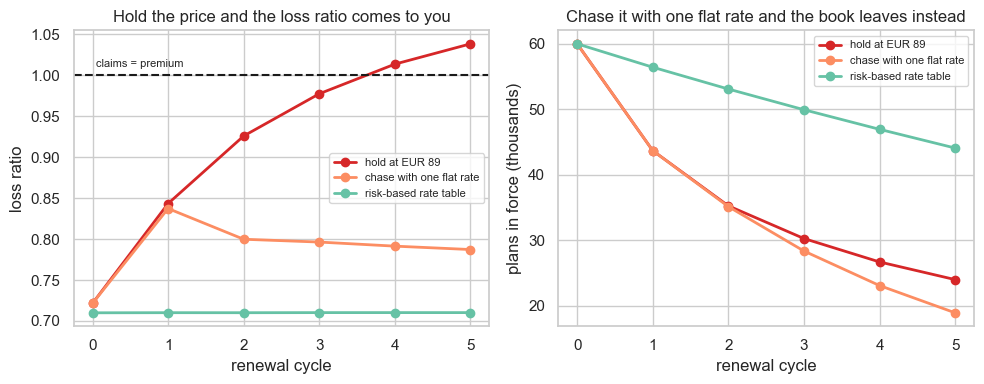

In [21]:
# FIG 4 -- the spiral, both symptoms
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
COL = {"hold at EUR 89": "#d62728", "chase with one flat rate": "#fc8d62",
       "risk-based rate table": "#66c2a5"}
for name, path in paths.items():
    axes[0].plot(path.cycle, path.loss_ratio, "-o", color=COL[name], lw=2, label=name)
    axes[1].plot(path.cycle, path.in_force / 1000, "-o", color=COL[name], lw=2, label=name)
axes[0].axhline(1.0, color="k", ls="--", lw=1.5)
axes[0].text(0.05, 1.01, "claims = premium", fontsize=8)
axes[0].set_xlabel("renewal cycle"); axes[0].set_ylabel("loss ratio")
axes[0].set_title("Hold the price and the loss ratio comes to you")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("renewal cycle"); axes[1].set_ylabel("plans in force (thousands)")
axes[1].set_title("Chase it with one flat rate and the book leaves instead")
axes[1].legend(fontsize=8)
plt.tight_layout()

Three futures, one book:

- **Hold at €89.** The loss ratio climbs **0.722 → 0.843 → 0.926 → 0.978 → 1.014 → 1.038** and the book falls from 60,000 plans to **23,999**. By cycle 4 the product pays out more than it takes in, *at an unchanged price*, purely because of who is left. Nothing about the risks changed; the *mix* did. Earned premium: €5.34 m → **€2.14 m**.
- **Chase with one flat rate.** The loss ratio behaves — it hovers around 0.79, because each year's price is reset to cover last year's book — but the price to do it goes **€89.00 → €89.65 → €103.21 → €112.56 → €121.43 → €129.51**, and the book collapses harder, to **18,928 plans**. You have not solved the problem; you have converted a loss-ratio problem into a volume problem, and you are now the most expensive flat-price plan on the market, sold to the worst risks. A 45 % rate increase in five years is also, in most markets, a conversation with a regulator.
- **The rate table.** Loss ratio flat at **0.71**, average price flat at **€90.45**, and the only lapses are the 6 % baseline — 44,090 plans still in force and **€3.99 m** of premium, against €2.14 m for holding and €2.45 m for chasing.

> ⚠️ **The spiral is not driven by bad customers. It is driven by good ones leaving.** Every cycle's damage is done by the departure of policies that were *profitable* — the consumer monitors, the suburban printers — because a flat price is only ever attractive to people it undercharges. This is why "we don't segment, we treat everyone the same" is not a neutral stance in insurance: it is a standing offer to your competitors to take your best customers, one segment at a time. (Our elasticity is deliberately brisk so five cycles show what fifteen would show at a real device-plan's stickiness. The speed is dialled; the direction is not.)

So the answer is a rate table. Which raises the two questions that stop it from being a spreadsheet exercise.

### 6.1 Permissible is not the same as predictive

A3's honest section put it in one sentence: *you must not use protected characteristics, nor proxies that reconstruct them, and dropping the protected column is not a defence.* Insurance is where that rule has the sharpest legal teeth. Since December 2012 — when the CJEU's ***Test-Achats*** ruling closed the exemption in the EU Gender Directive — European insurers may not use gender in pricing **at all**, including in the lines where it is demonstrably and strongly predictive. The law is not confused about the statistics. It has decided that some predictive factors are not *permissible* ones, and "but the data says so" is not an argument that engages with the question.

DeviceCare's product team has bought an affluence/credit score, `credit_band`, and it looks extremely promising:

In [22]:
univariate = pol.groupby("credit_band").agg(policy_years=("exposure", "sum"), claims=("claims", "sum"))
univariate["frequency"] = univariate.claims / univariate.policy_years
univariate["relativity"] = univariate.frequency / univariate.frequency.loc["average"]
print("univariate -- what the vendor's slide shows:")
print(univariate.loc[["strong", "average", "weak"]].round(4).to_string())

with_band = smf.glm(FREQ_FORMULA + " + C(credit_band, Treatment('average'))", data=pol,
                    family=sm.families.Poisson(), offset=pol.log_exposure).fit()
print("\nafter controlling for device / segment / channel / district / usage:")
for k in [i for i in with_band.params.index if "credit_band" in i]:
    print(f"  {k.split('T.')[1][:-1]:>8}: relativity {np.exp(with_band.params[k]):.3f}  "
          f"(p = {with_band.pvalues[k]:.3f})")
print(f"\ndeviance drop {freq_glm.deviance - with_band.deviance:.1f} on 2 df;  "
      f"AIC {freq_glm.aic:,.0f} -> {with_band.aic:,.0f}  (worse)")
print("\nwhat credit_band is actually made of (row %):")
print(pd.crosstab(pol.credit_band, pol.segment, normalize="index").round(3).to_string())

univariate -- what the vendor's slide shows:
             policy_years  claims  frequency  relativity
credit_band                                             
strong         12165.7375    1166     0.0958      0.7885
average        12446.8222    1513     0.1216      1.0000
weak           12064.2321    2115     0.1753      1.4422



after controlling for device / segment / channel / district / usage:
    strong: relativity 1.019  (p = 0.663)
      weak: relativity 1.014  (p = 0.714)

deviance drop 0.3 on 2 df;  AIC 32,462 -> 32,466  (worse)

what credit_band is actually made of (row %):
segment        SME  consumer  trade
credit_band                        
average      0.449     0.467  0.085
strong       0.246     0.738  0.016
weak         0.506     0.178  0.316


The vendor's slide is true: **weak-band customers claim 1.44× as often as average-band ones, strong-band 0.79×.** A 1.8× spread from a single purchased column.

And it is worth **nothing**. Put it in the model alongside the factors we already have and both relativities collapse to **1.01–1.02** with p-values of **0.66 and 0.71**; the deviance falls by 0.3 on 2 degrees of freedom and the AIC gets *worse*. The cross-tab says why: the "weak" band is 50.6 % SME and 31.6 % trade, the "strong" band is 73.8 % consumer. The score was never measuring credit behaviour — it was measuring, at one remove, *who the customer is and where they live*, which the rate table already prices directly and better.

That gives the committee two independent reasons to refuse it, and the order matters:

1. **It adds nothing.** Once device, segment, channel, district and usage are in the model, the score is noise. This is the cheapest test to run and it disposes of most proxy candidates.
2. **Even if it did add something, it would still be a proxy.** Affluence scores correlate with characteristics that European insurance law and the webshop's own conduct policy put out of bounds, and a factor whose *only* causal story is "poorer customers are worse risks" cannot be defended to a regulator, a journalist, or the customer receiving the surcharge. A3's Stretch C made the mechanism concrete: a model that never sees a protected attribute can still reproduce it faithfully through `sector` and postcode.

The factors that stay in the table all pass a stricter test than "is it predictive?": **is it a property of the insured risk, and can I explain to the customer why it moves their price?** Device type, declared usage and district are the object, its wear and its environment. Segment is what the object is used for. Credit band is who the customer is. That is the line, and it is drawn before the p-values are looked at, not after.

> 📌 **The one carve-out worth naming.** `district` survives here because it proxies for *theft and damage exposure at the device's location* — a physically causal story with an audit trail. Postcode rating is legal and standard in European property lines for exactly that reason, and it is also, in every market, the factor most likely to be reconstructing something else. The honest position is not "district is fine"; it is "district is in the table with a written justification and a redlining audit against it every year."

### 6.2 The glide path — a business constraint, priced

The other thing that stops the rate table being a spreadsheet: **you cannot hand an existing customer a 158 % increase.** Trade × laptop should pay €229.97 and pays €89. Sending that renewal notice would be commercially and reputationally indefensible even though every number behind it is right.

So the committee imposes a **cap of +25 % per renewal** on in-force customers (new business goes straight onto the technical rate). That is a legitimate business decision — and like every business decision in this module it has a price, which is our job to state rather than to hide.

In [23]:
YOY_CAP = 1.25
pol["year1_price"] = np.minimum(pol.technical, PRICE_FLAT * YOY_CAP)
foregone = ((pol.technical - pol.year1_price) * pol.exposure).sum()

print(f"plans hitting the +{YOY_CAP - 1:.0%} cap in year 1 : {(pol.technical > PRICE_FLAT * YOY_CAP).mean():.1%}")
print(f"premium foregone in year 1              : EUR {foregone:,.0f}")
print(f"  (against a book-wide underwriting margin of EUR "
      f"{(1 - (LR + EXP_VAR + EXP_FIX / PRICE_FLAT)) * pol.earned.sum():,.0f} -- the glide path costs "
      f"{foregone / ((1 - (LR + EXP_VAR + EXP_FIX / PRICE_FLAT)) * pol.earned.sum()):.1f}x this year's profit)")

print("\nrenewals needed to reach the technical price:")
for _, r in rate_table.iterrows():
    steps = int(np.ceil(np.log(max(r.technical, PRICE_FLAT) / PRICE_FLAT) / np.log(YOY_CAP)))
    verdict = "decrease -- apply in full immediately" if r.technical < PRICE_FLAT else f"{steps} renewal(s)"
    print(f"  {r.segment:>8} x {r.device:<8} EUR {PRICE_FLAT:6.2f} -> {r.technical:7.2f}   {verdict}")

plans hitting the +25% cap in year 1 : 25.4%
premium foregone in year 1              : EUR 464,879
  (against a book-wide underwriting margin of EUR 151,832 -- the glide path costs 3.1x this year's profit)

renewals needed to reach the technical price:
  consumer x monitor  EUR  89.00 ->   41.88   decrease -- apply in full immediately
       SME x monitor  EUR  89.00 ->   53.16   decrease -- apply in full immediately
  consumer x printer  EUR  89.00 ->   55.25   decrease -- apply in full immediately
       SME x printer  EUR  89.00 ->   72.87   decrease -- apply in full immediately
     trade x monitor  EUR  89.00 ->   82.66   decrease -- apply in full immediately
  consumer x laptop   EUR  89.00 ->   94.16   1 renewal(s)
     trade x printer  EUR  89.00 ->  120.07   2 renewal(s)
       SME x laptop   EUR  89.00 ->  131.56   2 renewal(s)
     trade x laptop   EUR  89.00 ->  229.97   5 renewal(s)


**€464,879 in year one** — roughly three times the whole book's current underwriting margin — to avoid sending fifteen thousand customers an unacceptable letter. That is not an argument against the cap; it is the cap's invoice, and a committee that sees it can weigh it against the alternative (a lapse spike, a consumer-affairs story, a reseller channel in revolt) instead of pretending the glide path is free.

Note the asymmetry in the last printout, because it is the part rate-change programmes get wrong: **decreases go through immediately and in full.** Consumer × monitor drops from €89 to €41.88 on the next renewal. Capping increases while sitting on decreases is not prudence, it is the death spiral with extra steps — you would be holding the overpriced good risks at €89 while the underpriced bad risks glide gently upward, which is precisely the mix shift §6 just simulated. The cap protects the customer from a shock; it must not protect the insurer from a rate cut.

**The decision, then, in the form the product committee signs:**

| | |
|---|---|
| **Rate table** | nine cells, €41.88 – €229.97, from `frequency × capped severity + €8.12 load`, loaded by `(pp + 7.50) / 0.80` |
| **Rating factors** | device, segment, declared usage, district — each a property of the insured risk, each with a written justification |
| **Excluded** | `credit_band` (adds nothing; would be a proxy even if it did) |
| **New business** | technical rate from day one |
| **Renewals** | increases capped at +25 %/yr (year-1 cost **€464,879**); decreases in full, immediately |
| **Large losses** | capped at €2,500 per claim; the €8.12/policy-year excess load is reviewed annually and is the natural attachment point for reinsurance |
| **Review trigger** | loss ratio by cell, quarterly; any cell above 0.85 goes back to the committee |

## 7. What real pricing teams add (honest section)

Everything above is the load-bearing 80 %. What a working pricing function layers on top — and what this notebook quietly assumed away:

- **Reserving and IBNR — the claims you owe but haven't seen.** Our `incurred` column is a fiction of the friendliest kind: it assumes every claim that happened this year has been reported *and* settled at its final amount. Neither is true. Claims arrive late (a laptop dropped on 28 December is reported in January) and they *develop* (the first estimate on a theft is rarely the cheque). Real loss ratios are computed on **incurred = paid + case reserves + IBNR**, where IBNR ("incurred but not reported") is itself an estimate, produced by chain-ladder or Bornhuetter–Ferguson methods on a claims-development triangle. The practical consequence is brutal for pricing: the most recent policy year — the one you most want to rate on — is the one whose loss ratio is least known, and the temptation to read an immature year as good news is how portfolios get underpriced. A pricing analysis that quotes an unreserved loss ratio is quoting a number that will get worse.
- **Reinsurance.** §4's cap is a pricing device; its operational twin is a real contract. An excess-of-loss treaty attaching at €2,500 transfers exactly the layer we loaded for, and the reinsurer's quoted price is a market check on our €8.12 — if they want €14, our tail estimate is optimistic or our data is thin. Reinsurance also buys capital relief, which feeds straight back into the `CAP_LOAD` in the denominator.
- **Credibility theory.** §5's nine cells are comfortable; a real rate table has hundreds, most of them thin. Actuaries do not choose between "use the cell's own experience" and "use the portfolio average" — they blend, with a weight $Z = n/(n+k)$ that rises with the cell's claim count. That is the same shrinkage idea this course has now met three times: A6's Stretch A shrank customer payment histories toward the ledger mean, A8 imposed a volume floor before ranking suppliers, and 🧠 Stretch A below does the actuarial version. Bühlmann credibility is empirical Bayes with an actuarial passport.
- **GLM → GBM, and why the GLM stays.** Gradient boosting beats a GLM on out-of-sample loss cost, routinely and by enough to matter, and every large European motor and home book now has one somewhere in its pricing stack. It usually sits *behind* the GLM rather than replacing it: the GBM finds interactions and non-linearities, which are then written back into the GLM as new factors or bands. The reason is not nostalgia. A filed rate table has to be a table — auditable, explainable to a customer who asks why their price went up, stable when one van gets stolen, and defensible against a regulator asking whether it is a proxy for something. The EU AI Act's risk-tiering (NB 52) reaches pricing models used in insurance, and "it's a gradient boosting model" is not an answer to "justify this individual price".
- **Renewal and lifetime pricing.** Everything here is one-shot technical pricing: what does this policy-year cost. Real pricing optimises over a *relationship* — acquisition cost is paid once and earned back over years, so a new-business price below technical can be rational; conversely, "price walking" (quietly increasing renewal prices for customers who never shop) was profitable for a decade and is now banned outright in the UK and under supervisory pressure across the EU. Lifetime pricing needs a lapse model, which needs the elasticity §6 assumed — and that elasticity has to be *measured*, which means A2's experiments and A4's uplift discipline, applied to rate changes.
- **What else a real book needs.** Deductibles and excesses (🧠 Stretch D) as both a price lever and a moral-hazard control; claims fraud detection (NB 24, wearing an insurance badge); catastrophe modelling for correlated losses, since our fleet thefts were independent and real ones are not; and a regulatory capital calculation (Solvency II), which is where `CAP_LOAD` stops being a constant we typed in and becomes the output of a whole other model.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | 60,000 plans at one flat €89; combined ratio looks fine | LR **0.729**, combined **0.953**, margin **€151,832** |
| 1 | …until you split it nine ways | consumer × monitor **0.24** vs trade × laptop **2.50** |
| 2 | Exposure is A5's censoring in actuarial clothes | naive 0.0799 vs earned **0.1307** — the naive figure is **38.9 % low** |
| 3 | Poisson GLM with `offset=log(exposure)` recovers the planted truth | laptop **1.89** (1.86), trade **1.69** (1.75), usage **1.098**/h (1.094) |
| 3 | Dispersion check: variance ≫ mean | var/mean **2.01** in one cell; α = **2.82** vs planted 2.86 |
| 3 | What overdispersion breaks | relativities move **0.3 %**; standard errors widen **12–18 %** |
| 4 | The mean is not a typical claim | mean **€497** vs median **€269**; top 1 % of claims = **17.1 %** of euros |
| 4 | Capping moves the loss, it does not delete it | 74 claims capped → **€8.12/policy-year** load on everyone |
| 5 | The technical price, cell by cell | **€41.88 → €229.97**, book average **€90.50** vs the flat €89 |
| 5 | The cross-subsidy a flat price hides | **€1,299,810/yr** = **39.8 %** of earned premium |
| 6 | Hold the flat price while a competitor rates risk | LR **0.722 → 1.038**, book **60,000 → 23,999** in five renewals |
| 6 | Chase it with one flat rate instead | price €89 → **€129**, book → **18,928**; premium €5.34 m → €2.45 m |
| 6 | Differentiate | LR flat at **0.71**, book **44,090**, premium **€3.99 m** |
| 6 | `credit_band`: predictive alone, worthless in the model | univariate **1.44×** → controlled **1.01×**, p = **0.71** |
| 6 | The glide path is a product, so it has a price | +25 %/yr cap costs **€464,879** in year one |

Three lessons to keep. **The unit is the model** — get exposure wrong and every euro downstream is wrong by the same 38.9 %. **The mean of a fat tail is a decision, not a measurement** — where you cap and who pays for the excess is a policy choice you make before you know where the tail will land. And **a price that is right on average is not right**: the market prices each customer individually whether you do or not, and the customers you lose to it are exactly the ones you were counting on.

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ Where else is the book leaking?

§1 sliced the book by segment × device. Two rating factors did not get a loss-ratio table of their own: `channel` and `district`. Build both with `book()`, name the worst corner of each, and then answer the question a product manager will ask immediately: *"are these new problems, or are we looking at the trade segment again from a different angle?"* Use the §3 GLM relativities to argue it.

In [24]:
# Starter
# book(pol, "channel")[["policy_years", "freq", "pure_prem", "loss_ratio"]]
# then the same for "district" -- and compare with the fitted relativities in `recovery`

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
for factor in ["channel", "district"]:
    t = book(pol, factor)[["policy_years", "claims", "freq", "pure_prem", "loss_ratio"]]
    print(f"\n--- {factor} ---")
    print(t.sort_values("loss_ratio").round(3).to_string())

print("\nfitted relativities (which SURVIVE controlling for everything else):")
print(recovery.loc[[i for i in recovery.index if "channel" in i or "district" in i],
                   ["relativity", "planted truth"]].round(3).to_string())
```

**Telesales runs a 0.85 loss ratio against the webshop's 0.69; inner city runs 0.83 against rural's 0.57.** Both are real and both are already priced — the GLM puts telesales at **1.22×** and inner city at **1.23×** *after* controlling for device, segment, usage and each other, so they are independent signals rather than the trade segment in disguise. (Compare with `credit_band` in §6.1, which does *not* survive that test: that is the whole difference between a rating factor and a proxy.)

The follow-up is worth spelling out, because it is where this exercise stops being a `groupby`. A loss ratio by X is a **marginal** number; a GLM relativity is a **conditional** one, and they agree only when X is uncorrelated with the rest of the rating factors. Here they nearly do (telesales' raw pure premium is 1.24× the webshop's, its fitted relativity 1.22×) because the generator drew channel, district, device and segment independently. In a real book they never agree — telesales sells to trade, trade buys laptops — and rating on the raw ratio would charge the same risk two or three times over. That is what a multiplicative GLM exists to prevent, and why "loss ratio by X" is a diagnostic, never a rate.
</details>

### Exercise 2 — ⭐⭐ The cap is a dial

§4 capped at €2,500 because it looked sensible. Turn it into a parameter: for caps of **€1,000, €2,500, €10,000 and no cap**, recompute the large-loss load, refit the severity GLM on the capped amounts, and report (a) the load, (b) the trade × laptop technical price, (c) the consumer × monitor technical price, and (d) the book-average technical price. Which of the four numbers barely moves, and what does that tell you about what a cap actually is?

In [25]:
# Starter
# for cap_at in (1_000.0, 2_500.0, 10_000.0, np.inf):
#     capped = clm.amount.clip(upper=cap_at)
#     load = (clm.amount - capped).sum() / PY
#     refit the Gamma GLM on `capped`, predict on pol, rebuild the technical price

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rows = []
for cap_at in (1_000.0, 2_500.0, 10_000.0, np.inf):
    capped_amt = clm.amount.clip(upper=cap_at)
    load = (clm.amount - capped_amt).sum() / PY
    g = smf.glm("y ~ C(device, Treatment('monitor')) + C(segment, Treatment('consumer'))",
                data=clm.assign(y=capped_amt),
                family=sm.families.Gamma(link=sm.families.links.Log())).fit()
    tmp = pol.copy()
    tmp["t"] = (tmp.freq_hat * g.predict(tmp) + load + EXP_FIX) / LOAD_DIV
    tl = tmp[(tmp.segment == "trade") & (tmp.device == "laptop")]
    cm = tmp[(tmp.segment == "consumer") & (tmp.device == "monitor")]
    rows.append(dict(cap=cap_at, pierced=int((clm.amount > cap_at).sum()), load=load,
                     trade_laptop=np.average(tl.t, weights=tl.exposure),
                     consumer_monitor=np.average(cm.t, weights=cm.exposure),
                     book=np.average(tmp.t, weights=tmp.exposure)))
print(pd.DataFrame(rows).round(2).to_string(index=False))
```

| cap | load | trade × laptop | consumer × monitor | book |
|---|---|---|---|---|
| €1,000 | €16.30 | €202.58 | €50.63 | €90.50 |
| €2,500 | €8.12 | €229.97 | €41.88 | €90.50 |
| €10,000 | €2.96 | €258.34 | €37.43 | €90.48 |
| none | €0.00 | €274.50 | €35.29 | €90.46 |

**The book-average price does not move — €90.46 to €90.50 across the whole range.** The cap has no opinion about how much premium the portfolio needs; it only decides **who pays it**. Tighten it to €1,000 and the trade laptop rate falls €72 while the consumer monitor rate rises €15; remove it entirely and trade × laptop absorbs the full weight of whichever catastrophes happened to land there this year.

That makes the choice of cap an explicit trade-off between two errors, and neither is "safe": a low cap is **stable but blunt** (it charges a customer who will never have a €20,000 loss for the possibility that someone will), a high cap is **sharp but noisy** (rerun the generator with a different seed and the €274.50 moves by tens of euros). Practitioners choose it by looking at where the empirical severity distribution stops being credible per cell — often a fixed percentile, or a multiple of the average claim — and they document it, because it is a judgement call that a later reviewer must be able to find.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the model that priced new business a third too cheap

A colleague fits the frequency model, prices a new full-year trade laptop plan, and files it. Their code runs perfectly:

```python
bad = smf.glm(FREQ_FORMULA, data=pol, family=sm.families.Poisson()).fit()   # <- no offset

new_plan = pd.DataFrame([dict(device="laptop", segment="trade", channel="reseller",
                              district="inner city", usage=8.0, usage_c=3.0, exposure=1.0)])
freq_bad = bad.predict(new_plan)[0]
price_bad = (freq_bad * sev_glm.predict(new_plan)[0] + excess_load + EXP_FIX) / LOAD_DIV
print(f"trade laptop, 12 months of cover: EUR {price_bad:.2f}")   # -> 'EUR 174.50, ship it'
```

Run the starter, reproduce their number, then find the flaw and produce the price they should have filed. Second part: a different colleague, told about offsets, "fixes" it by adding `+ exposure` to the formula as an ordinary feature. Fit that too — is it fixed?

In [26]:
# Starter -- their exact pipeline (it runs; that is the problem)
bad = smf.glm(FREQ_FORMULA, data=pol, family=sm.families.Poisson()).fit()

new_plan = pd.DataFrame([dict(device="laptop", segment="trade", channel="reseller",
                              district="inner city", usage=8.0, usage_c=3.0, exposure=1.0)])
freq_bad = bad.predict(new_plan)[0]
price_bad = (freq_bad * sev_glm.predict(new_plan)[0] + excess_load + EXP_FIX) / LOAD_DIV
print(f"no-offset frequency: {freq_bad:.4f} claims/year -> price EUR {price_bad:.2f}")

no-offset frequency: 0.2208 claims/year -> price EUR 174.50


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
freq_good = freq_glm.predict(new_plan, offset=np.array([0.0]))[0]
sev_new = sev_glm.predict(new_plan)[0]
price_good = (freq_good * sev_new + excess_load + EXP_FIX) / LOAD_DIV
print(f"no-offset : {freq_bad:.4f} claims/yr -> EUR {price_bad:.2f}")
print(f"with offset: {freq_good:.4f} claims/yr -> EUR {price_good:.2f}")
print(f"the filed price is off by {price_bad / price_good - 1:.1%}\n")

worse = smf.glm(FREQ_FORMULA + " + exposure", data=pol, family=sm.families.Poisson()).fit()
print(f"exposure as a plain feature: coefficient {worse.params['exposure']:.3f} "
      f"(an offset would force exactly 1.000)")
print(f"  full-year prediction {worse.predict(new_plan)[0]:.4f} vs correct {freq_good:.4f}")
half = new_plan.assign(exposure=0.5)
print(f"  half-year prediction {worse.predict(half)[0]:.4f} vs correct {freq_good * 0.5:.4f} "
      f"({worse.predict(half)[0] / (freq_good * 0.5) - 1:+.0%})")
```

**€174.50 filed against a technical €273.33 — the price is 36 % too cheap**, and the same error runs through every quote the model produces. The cause is §2 with a regression wrapped round it: without an offset the model learns *claims per policy*, not *claims per policy-year*, so it predicts **0.2208** claims a year for a plan that will actually produce **0.3616** — a ratio of 0.611, which is the book's mean exposure to three decimal places. The model was never wrong about the data it was shown; it was answering a different question, in different units, silently.

The "fix" is worse than it looks. Adding `exposure` as a feature lets the model *estimate* its coefficient, and it comes out at **1.849** rather than the 1.000 an offset would impose — so on the log scale exposure gets a multiplier of its own choosing. At exactly one year of exposure it happens to land within 4 % of the right answer (0.3762 against 0.3616); at half a year it is **17 % low** (0.1492 against 0.1808), and it cannot extrapolate to the three-year term the product is actually sold on at all. An offset is not a modelling preference. It is the statement *"one policy-year of exposure produces one policy-year of claims"*, which is arithmetic, and letting a regression argue with arithmetic is how you end up filing €174.50.
</details>

### Exercise 4 — ⭐⭐ The glide path, fully costed

§6.2 priced the first year of the +25 % cap. Cost the **whole** path: for each renewal cycle until every cell reaches its technical price, compute the capped price per cell, the premium foregone that year, and the cumulative total. Then compare it with two alternatives: **(a)** a +40 % cap, and **(b)** closing trade × laptop to new business and letting the existing plans run off at €89. Which is cheapest, and which would you actually recommend?

In [27]:
# Starter
# price_t = min(technical, PRICE_FLAT * cap**t)  for t = 1, 2, 3, ...
# foregone_t = sum over cells of (technical - price_t) * policy_years

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def glide_cost(cap_factor, cycles=6):
    rows = []
    for t in range(1, cycles + 1):
        price_t = np.minimum(pol.technical, PRICE_FLAT * cap_factor ** t)
        gone = ((pol.technical - price_t) * pol.exposure).sum()
        rows.append(dict(cycle=t, foregone=gone))
    out = pd.DataFrame(rows)
    out["cumulative"] = out.foregone.cumsum()
    return out

for cap_factor in (1.25, 1.40):
    g = glide_cost(cap_factor)
    print(f"\n--- cap +{cap_factor - 1:.0%} per renewal ---")
    print(g.round(0).to_string(index=False))

tl = rate_table[(rate_table.segment == "trade") & (rate_table.device == "laptop")].iloc[0]
runoff = (tl.technical - PRICE_FLAT) * tl.policy_years
print(f"\n(b) trade x laptop closed to new business, existing plans run off at EUR 89:")
print(f"    cost EUR {runoff:,.0f}/yr while they run off, and the cell's "
      f"{tl.policy_years:,.0f} policy-years of premium leave the book at expiry")
```

The **+25 % cap costs €464,879 in year 1, €272,048 in year 2 and €149,181 in year 3**, tapering to nothing by year 6 — a cumulative bill of **€990,224**. The **+40 % cap** costs **€357,156** in year 1 and is effectively done in three renewals, **€554,789** in total: twice as fast and 44 % cheaper, but considerably more likely to produce lapses and complaints in the cells that jump hardest. Running trade × laptop off at €89 costs **€320,933 a year** for as long as those plans stay on the books, and unlike the glide path it never converges — you are paying to keep a loss-making cell rather than paying to fix it.

The recommendation is not the cheapest option. It is the **+25 % cap on the two laptop cells, +40 % elsewhere, decreases in full immediately** — because the constraint the cap exists to satisfy is not financial, it is "what can we defend in a renewal letter", and that constraint bites hardest exactly where the increase is largest. Costing all three paths is what lets the committee buy the defensible one deliberately, at a known price, instead of discovering it in a complaints report.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Credibility: what a thin cell is allowed to say

Split the book into **segment × device × district** — 27 cells instead of 9 — and compute each cell's raw pure premium. Several will be built on fewer than 50 claims, and their estimates will be wild. Apply **Bühlmann-style credibility**: shrink each cell's raw pure premium toward the portfolio mean with weight $Z = n/(n+k)$ where $n$ is the cell's claim count and $k$ a credibility constant (start at $k = 50$). Report the raw and shrunk estimates for the six thinnest cells, and say what $k$ actually controls. Then the honest question: the §5 GLM already gives a number for every one of these cells without any shrinkage step — what is it doing instead, and when would you still want the explicit blend?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
K = 50.0
thin = pol.groupby(["segment", "device", "district"]).agg(
    policy_years=("exposure", "sum"), claims=("claims", "sum"), incurred=("incurred", "sum"))
portfolio_pp = pol.incurred.sum() / PY
thin["raw_pp"] = thin.incurred / thin.policy_years
thin["Z"] = thin.claims / (thin.claims + K)
thin["credible_pp"] = thin.Z * thin.raw_pp + (1 - thin.Z) * portfolio_pp
thin["glm_pp"] = (pol.groupby(["segment", "device", "district"])
                     .apply(lambda g: np.average(g.pure_prem, weights=g.exposure),
                            include_groups=False))
print(f"portfolio pure premium: EUR {portfolio_pp:.2f}   cells: {len(thin)}   "
      f"median claims/cell: {thin.claims.median():.0f}")
print(thin.nsmallest(6, "claims")[["policy_years", "claims", "raw_pp", "Z",
                                   "credible_pp", "glm_pp"]].round(2).to_string())
print("\nspread of estimates (std across cells):")
print(f"  raw       {thin.raw_pp.std():.2f}")
print(f"  credible  {thin.credible_pp.std():.2f}")
print(f"  GLM       {thin.glm_pp.std():.2f}")
```

The thinnest cells carry **40–70 claims** and get $Z \approx 0.45$–$0.58$ — they are allowed roughly half a vote, and the portfolio mean supplies the rest. `trade × printer × rural` has a raw pure premium of **€50.39** on 42 claims; credibility pulls it to **€58.28**, and the GLM — which never saw that cell as a cell — puts it at **€68.05**. All three numbers are defensible and they disagree, which is the point of the exercise. Look at the spread of estimates across all 27 cells: standard deviation **€60.10** raw, **€47.35** shrunk, **€44.60** from the GLM. Both methods are doing the same job; they differ in how much they let a thin cell shout.

$k$ is the **claim count at which a cell earns half a vote**, and it encodes a genuine prior: how much do you believe cells really differ, relative to how noisy a single cell's experience is? Formally $k = \sigma^2_{\text{within}} / \sigma^2_{\text{between}}$ — small $k$ if cells are genuinely heterogeneous, large $k$ if the differences you see are mostly sampling noise.

And the honest question: **the GLM is already shrinking, structurally rather than explicitly.** By insisting the rate is a *product* of a few main effects it borrows every cell's estimate from every other cell that shares a level — `trade × printer × rural` is estimated from all trade plans, all printers and all rural plans at once, which is why it never produces a wild number even on 42 claims. That is stronger shrinkage than credibility, and it costs something: any genuine interaction (rural trade printers really being different) is assumed away. Explicit credibility earns its keep exactly there — on residuals after the GLM, on high-cardinality factors the GLM cannot take (vehicle model, occupation code, postcode sector), and anywhere you want the blending weight to be visible and arguable rather than implied by the model's functional form. Modern practice does both: a GLM for structure, credibility or a random effect for the levels the GLM cannot resolve.
</details>

### Stretch exercise B — ⭐⭐⭐ One model instead of two: the Tweedie GLM

The two-part frequency × severity structure is not the only way to price. A **Tweedie** GLM (`sm.families.Tweedie(var_power=p, link=log)` with $1 < p < 2$) models the pure premium *directly* — the Tweedie is a compound Poisson–Gamma, exactly the process that generated our data, so a single regression on `incurred / exposure` (weighted by exposure) estimates the same quantity in one step. Fit it with `var_power=1.6`, compare its cell pure premiums with the two-part model's and with the empirical burning cost, then explain the one systematic disagreement you will find — it is not a bug, and §4 already told you where it comes from.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
pol["burning_cost"] = pol.incurred / pol.exposure          # EUR per policy-year, per plan
tweedie = smf.glm(FREQ_FORMULA.replace("claims ~", "burning_cost ~"), data=pol,
                  family=sm.families.Tweedie(var_power=1.6, link=sm.families.links.Log()),
                  var_weights=pol.exposure).fit()
pol["pp_tweedie"] = tweedie.predict(pol)

cmp = pol.groupby(["segment", "device"]).apply(lambda g: pd.Series({
    "two_part": np.average(g.pure_prem, weights=g.exposure),
    "tweedie": np.average(g.pp_tweedie, weights=g.exposure),
    "empirical": g.incurred.sum() / g.exposure.sum()}), include_groups=False)
print(cmp.round(2).to_string())
print(f"\nbook average -- two-part EUR {np.average(pol.pure_prem, weights=pol.exposure):.2f}  "
      f"tweedie EUR {np.average(pol.pp_tweedie, weights=pol.exposure):.2f}  "
      f"empirical EUR {pol.incurred.sum() / PY:.2f}")
```

The two agree closely everywhere except the extremes, and the disagreement runs one way: **Tweedie puts trade × laptop at about €213 where the two-part model says €176**, and puts consumer × monitor *below* the two-part figure. That is not a defect of either model — it is §4's cap, visible from a different angle. The two-part model was fitted on **capped** severities with the excess recycled as a flat €8.12 load, so it deliberately takes the tail *off* the cells where the tail happened to land and spreads it evenly. Tweedie was fitted on raw pure premium, so the €25,953 theft stays exactly where it fell and inflates that cell's rate. Tweedie is reproducing the empirical burning cost more faithfully, which sounds like a virtue until you remember that the empirical burning cost of that cell is partly an accident of where a van was parked.

What you gain from Tweedie: one model instead of two, one set of diagnostics, and no need to decide how to combine two sets of relativities — genuinely convenient, and it is the standard choice for lines with sparse claims. What you lose: **frequency and severity stop being separately visible**, and they are separately *actionable*. "Trade claims 1.7× as often" is a risk-selection and loss-prevention conversation (training, cases, tracking); "trade claims cost 1.13× more when they happen" is a claims-handling and deductible conversation. A single Tweedie coefficient of 1.9× on trade cannot tell you which one you are looking at. Most European pricing teams fit both and use Tweedie as a cross-check on the product of the two-part model, which is exactly what you just did.
</details>

### Stretch exercise C — ⭐⭐⭐ Bootstrap the rate table: which cells are actually different?

Every price in §5's table was quoted to the cent, on cells holding between 256 and 1,112 claims. Put error bars on them: for each cell, resample its policies with replacement (500 reps) and recompute the empirical pure premium, then convert the 2.5th and 97.5th percentiles into technical prices. Sort the table by pure premium and find the pairs of cells whose intervals overlap. Then answer the design question: given the overlaps, how many *distinct rate levels* can this book actually support?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rng_b = np.random.default_rng(7)
rows = []
for (seg, dev), g in pol.groupby(["segment", "device"]):
    inc, exp = g.incurred.to_numpy(), g.exposure.to_numpy()
    draws = rng_b.integers(0, len(g), size=(500, len(g)))
    boot_pp = inc[draws].sum(axis=1) / exp[draws].sum(axis=1)
    lo, hi = np.percentile(boot_pp, [2.5, 97.5])
    rows.append(dict(segment=seg, device=dev, claims=int(g.claims.sum()),
                     pure_prem=inc.sum() / exp.sum(),
                     tech_lo=(lo + EXP_FIX) / LOAD_DIV, tech_hi=(hi + EXP_FIX) / LOAD_DIV))
bt = pd.DataFrame(rows).sort_values("pure_prem").reset_index(drop=True)
bt["width_%_of_price"] = (bt.tech_hi - bt.tech_lo) / ((bt.tech_hi + bt.tech_lo) / 2)
print(bt.round(2).to_string(index=False))

print("\nadjacent cells whose 95% intervals OVERLAP (not distinguishable):")
for i in range(len(bt) - 1):
    a, b = bt.iloc[i], bt.iloc[i + 1]
    if a.tech_hi > b.tech_lo:
        print(f"  {a.segment} x {a.device}  [{a.tech_lo:.0f}, {a.tech_hi:.0f}]  vs  "
              f"{b.segment} x {b.device}  [{b.tech_lo:.0f}, {b.tech_hi:.0f}]")
```

The intervals are **21 % to 66 % of the price wide**, and the worst offenders are exactly the thin, tail-exposed cells: trade × monitor's technical price is somewhere in **[€64, €126]** and trade × printer's in **[€88, €163]**. **Seven of the eight adjacent pairs overlap** — only the final step up to trade × laptop is unambiguous. The two ends never come close: consumer × monitor sits in [€30, €45] and trade × laptop in [€240, €346], and no amount of resampling brings them near each other.

So the book supports far fewer than nine distinct rate levels — realistically **three or four bands**, something like *monitors and consumer printers* / *SME printers and trade monitors* / *laptops* / *trade laptops*. That is a genuinely useful finding and it is the argument the §5 table cannot make about itself: precision in a rate table is not free, and quoting nine prices when the data supports four means six of them are noise that customers will experience as arbitrariness. Note also what the bootstrap does *not* capture — it resamples the policies we have, so it prices the uncertainty in this book's tail, not the possibility that next year's tail is bigger. Compare each interval's width with §4's capping analysis: the cells with the widest intervals are the ones the cap was protecting in the first place.
</details>

### Stretch exercise D — ⭐⭐⭐ A €150 excess, and who chooses it

Product management proposes a cheaper variant: the same cover with a **€150 excess** the customer pays on every claim. Compute what the insurer's liability becomes (claims below €150 disappear entirely — they will not be filed), the new pure premium and technical price per cell, and the resulting discount as a percentage. Then the part that matters: the discount is **not the same percentage in every cell**. Say which customers a single flat "20 % off with a €150 excess" would attract, and what it would do to the book.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
EXCESS = 150.0
clm["net_of_excess"] = np.clip(clm.amount - EXCESS, 0, None)
print(f"claims that disappear entirely (below EUR {EXCESS:.0f}): "
      f"{(clm.amount <= EXCESS).mean():.1%}")
print(f"insurer pays {clm.net_of_excess.sum() / clm.amount.sum():.1%} of gross incurred\n")

net = (clm.groupby(["segment", "device"])
          .apply(lambda g: pd.Series({"gross": g.amount.sum(), "net": g.net_of_excess.sum()}),
                 include_groups=False))
net["keep_share"] = net.net / net.gross
cells_py = pol.groupby(["segment", "device"]).exposure.sum()
net["pp_full"] = (clm.groupby(["segment", "device"]).amount.sum() / cells_py)
net["pp_excess"] = net.net / cells_py
net["tech_full"] = (net.pp_full + EXP_FIX) / LOAD_DIV
net["tech_excess"] = (net.pp_excess + EXP_FIX) / LOAD_DIV
net["discount"] = 1 - net.tech_excess / net.tech_full
print(net[["keep_share", "tech_full", "tech_excess", "discount"]]
      .sort_values("discount").round(3).to_string())
```

A €150 excess wipes out **28.5 %** of all claims and cuts the insurer's liability to **73.3 %** of gross — but the effect is wildly uneven. On trade × laptop the insurer still pays **80.8 %** of gross (big claims, the excess is a rounding error), so the fair discount is small. On consumer × printer it pays **58.1 %**, and on consumer × monitor **62.3 %** — small frequent claims, where €150 removes half the book of claims outright. Once the fixed €7.50 expense is added back the *price* discount still ranges from **18.5 %** on trade laptops to **32.7 %** on consumer printers. (These are computed from each cell's raw claims rather than from §5's model, so the price *levels* differ from the rate table; the discount percentages are what the exercise is about.)

So a flat "20 % off with a €150 excess" is a mispriced product on both ends. It is **too generous to trade laptops** — whose losses barely shrink — and they will take it, buying a 20 % discount for an 18.5 % reduction in what they cost you. It is **too mean to the cheap cells**: consumer monitors would need 27.9 % off and consumer printers 32.7 % before the excess is worth accepting, so they stay on full cover — i.e. exactly the customers whose risk the excess actually removes are the ones who decline it. That is adverse selection again, generated this time not by a competitor but by your own product menu: **any option offered at one price to customers whose true cost of that option differs is a selection device**, and the people who take it are the people for whom it is underpriced. Excesses must be priced per rating cell, like everything else — and the same logic governs voluntary excess ladders, no-claims discounts and every optional cover in an insurance catalogue.
</details>

## 🎁 Bonus mini-project — the rate-change memo for the product committee

Write `rate_change_memo()` — the two pages the DeviceCare product committee actually votes on, generated entirely from the objects in this notebook, with every number traceable to a cell above it.

1. **Where we are.** Plans in force, earned premium, loss ratio, expense ratio, combined ratio and underwriting margin in euros — then the nine-cell loss ratio table with the two cells above 1.00 flagged, and the sentence that explains why the total looked fine.
2. **What the product costs.** The rate table: frequency, capped severity, large-loss load, pure premium, technical price per cell, with the loading formula written out. State the cap and the excess load explicitly, and name what a reinsurer would be asked to quote against.
3. **What the flat price is doing.** The cross-subsidy table in € per policy-year and € per year across the book, the gross total, and the §6 simulation in three lines: hold, chase, differentiate — loss ratio and in-force at cycle 5 for each.
4. **The proposal.** New-business rates from day one; renewal glide path with its cap and its year-one cost; decreases applied in full immediately; the rating factors in, the factors out, and *why* `credit_band` is out (both reasons, in that order); the quarterly review trigger.
5. **What we are not certain about.** Stretch C's intervals: which cells are genuinely distinguishable and which are being quoted with false precision; the fact that the loss ratios are unreserved (§7's IBNR paragraph) and will develop upward; and the one assumption in §6 that is not measured — the lapse elasticity — with a proposal for measuring it (a rate test on a randomised slice of renewals, A2's design, A4's discipline).

Format it as printed markdown, the way NB 23's memo does. Grading yourself: a committee member who has never opened a notebook should be able to challenge any line in it, because every line names its source — book fact, model output, or assumption. And there should be exactly one number in the memo that is *not* derived from the data: the loading you chose. Say so.

## ✅ Self-assessment checklist

- [ ] I can read a book of insurance in its own units — written vs earned premium, incurred claims, loss ratio, expense ratio, combined ratio — and say what each one hides.
- [ ] I can explain why exposure is the same problem as A5's censoring, compute an exposure-weighted frequency, and quantify the bias from ignoring it (38.9 % here, and it is a bias, not noise).
- [ ] I can fit a Poisson GLM with `offset=np.log(exposure)`, explain why the offset is not a feature, and say what happens to a new-business price without it.
- [ ] I can run a dispersion check, recognise overdispersion as unmeasured heterogeneity, and state precisely what it damages (intervals and tests) and what it leaves alone (relativities).
- [ ] I can explain why the mean of a fat-tailed severity is not a typical claim, and read a severity distribution by percentile instead.
- [ ] I can apply a large-loss cap, compute the excess load it creates, and defend the claim that a cap redistributes a loss rather than removing it — with the book-average price as evidence.
- [ ] I can assemble a technical price from frequency × severity plus expense and capital loadings, and explain why cheap covers carry proportionally huge loadings.
- [ ] I can quantify the cross-subsidy inside a flat price in € per policy-year and € per year across a book.
- [ ] I can describe the adverse-selection loop, say why it is driven by good risks leaving rather than bad ones arriving, and read a death-spiral simulation.
- [ ] I can distinguish a permissible rating factor from a predictive one, test a candidate factor for proxy behaviour, and state the two reasons to reject one in the right order.
- [ ] I can price a business constraint — a capped year-over-year increase — instead of treating it as free, and I know why decreases must not be capped too.
- [ ] I know what this notebook did not solve: IBNR and reserving, reinsurance, credibility for thin cells, GBMs behind the GLM, and lifetime rather than one-shot pricing.

---

## 🚀 Where next

- **[Back to the module README](README.md)** for the map of NB 23–26 and the appendix track.
- **A3** is this notebook's sibling: the same *model → money → decision* spine on a binary loss with a binary decision. Reread its selective-labels section — an insurer that declines to quote never learns what that risk would have cost, which is §6's problem seen from the underwriting side.
- **A5 §2** for the original of §2. Censoring and exposure are one idea with two vocabularies; if you can build a Kaplan–Meier curve you already understand why `offset=log(exposure)` is not optional.
- **A1** for the elasticity §6 assumed and **A2** for how you would measure it honestly — a rate test on a randomised slice of renewals is the only way the lapse curve in §6 stops being a guess.
- **Module 8 (`08_ai_engineering`)** — and NB 52 in particular, whose EU AI Act risk tiers reach exactly the pricing models §7's GLM-versus-GBM paragraph was about.

---

> 🧭  [◀ A11 — Routing & Allocation](./A11_routing_allocation.ipynb)  ·  [Module 7 index](./README.md)  ·  [A13 — Product Analytics ▶](./A13_product_analytics.ipynb)  ·  [🏠 Course home](../README.md)
